In [ ]:

!pip -q install opencv-python scikit-image scikit-learn tqdm

import os, glob, random, math, time
import numpy as np
import cv2
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, roc_auc_score,
    confusion_matrix, log_loss
)

from skimage.feature import local_binary_pattern, graycomatrix, graycoprops

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


from google.colab import drive
drive.mount('/content/drive')



Device: cuda
Mounted at /content/drive


In [ ]:
import os

DATA_ROOT = "/content/drive/My Drive/1-a-monkeypox/data2/"
print("Exists?", os.path.isdir(DATA_ROOT), DATA_ROOT)
print("Inside:", os.listdir(DATA_ROOT) if os.path.isdir(DATA_ROOT) else "NOT FOUND")

# sınıf klasörleri kontrol
for c in ["monkeypox","normal"]:
    p = os.path.join(DATA_ROOT, c)
    print(c, "->", os.path.isdir(p), "|", p)


Exists? True /content/drive/My Drive/1-a-monkeypox/data2/
Inside: ['monkeypox', 'normal', 'cv5_methods_results.csv', 'cv5_methods_summary.csv', 'cv5_graphcnn_resnet_results.csv', 'cv5_graphcnn_resnet_summary.csv']
monkeypox -> True | /content/drive/My Drive/1-a-monkeypox/data2/monkeypox
normal -> True | /content/drive/My Drive/1-a-monkeypox/data2/normal


Device: cuda

[DEBUG] DATA_ROOT alt klasörleri:
 - 'monkeypox'
 - 'normal'

Resolved class dirs: {'M-monkeypox': 'monkeypox', 'normal': 'normal'}

Total images: 572

[DEBUG] Class counts:
M-monkeypox -> 279 | dir: /content/drive/My Drive/1-a-monkeypox/data2/monkeypox
normal -> 293 | dir: /content/drive/My Drive/1-a-monkeypox/data2/normal

===== Fold 1/5 | train 388 | val 69 | test 115 =====

===== Fold 2/5 | train 388 | val 69 | test 115 =====

===== Fold 3/5 | train 389 | val 69 | test 114 =====

===== Fold 4/5 | train 389 | val 69 | test 114 =====

===== Fold 5/5 | train 389 | val 69 | test 114 =====


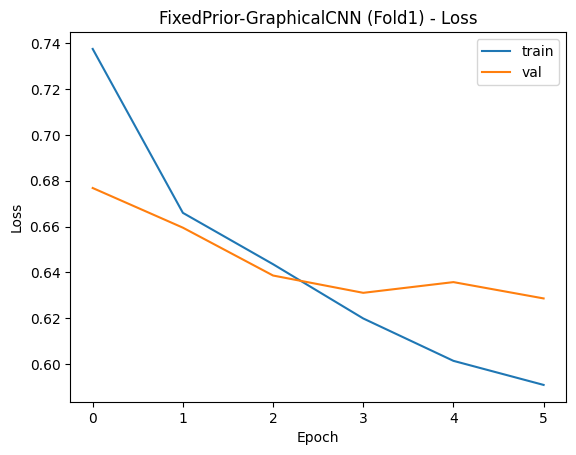

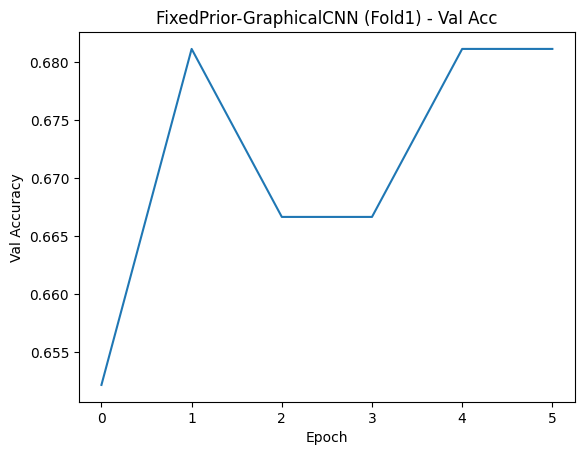

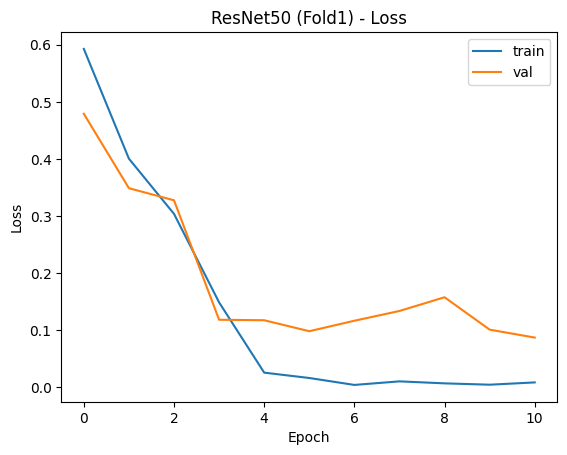

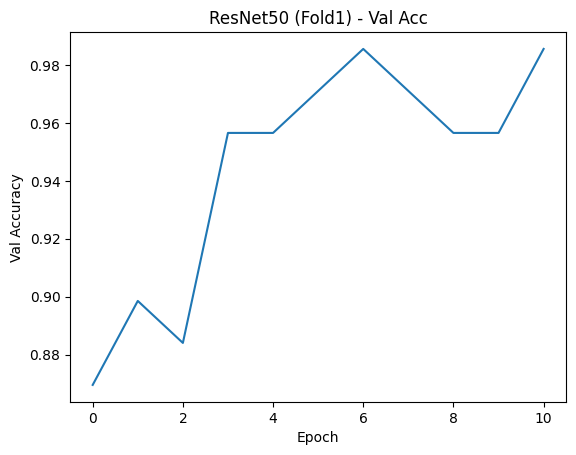

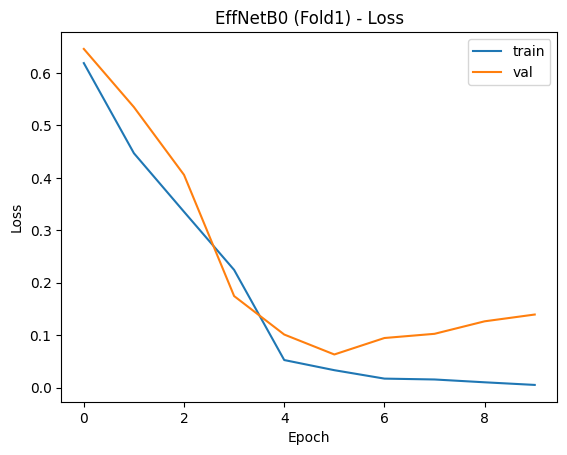

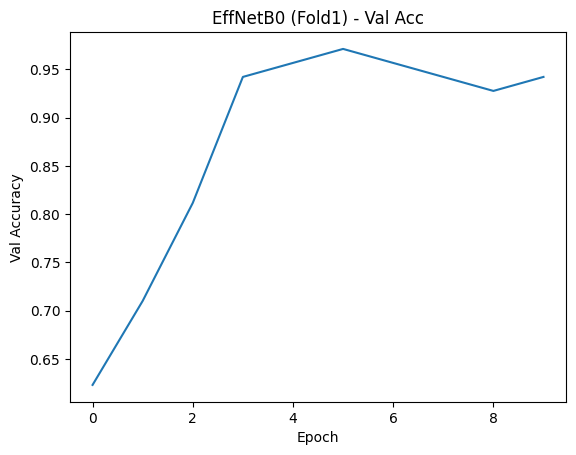

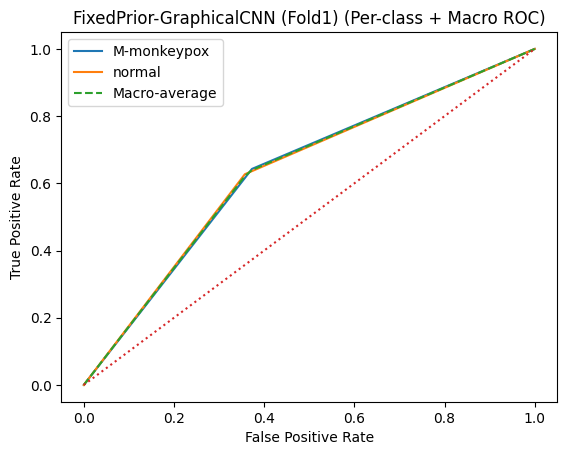

FixedPrior-GraphicalCNN (Fold1) | AUC(pos=normal): 0.6350


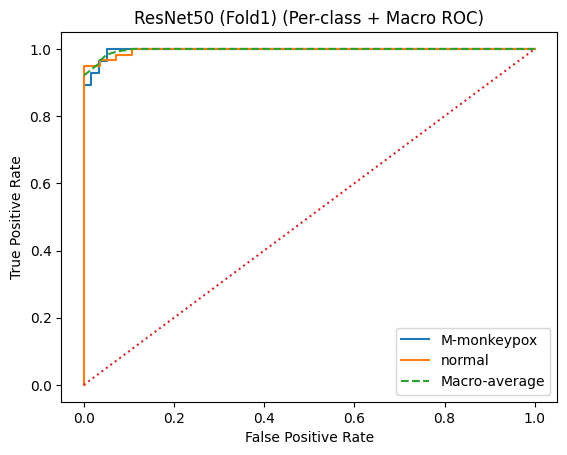

ResNet50 (Fold1) | AUC(pos=normal): 0.9964


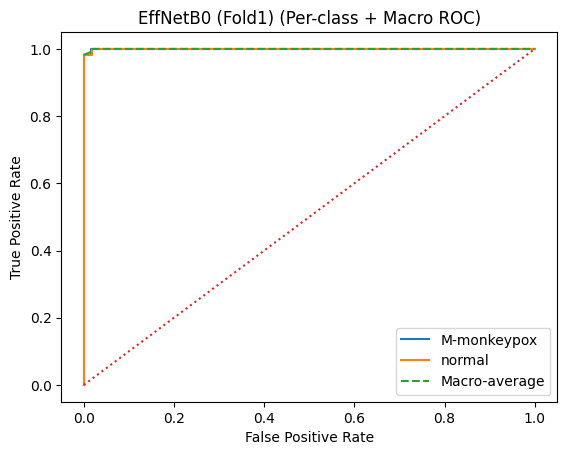

EffNetB0 (Fold1) | AUC(pos=normal): 0.9997


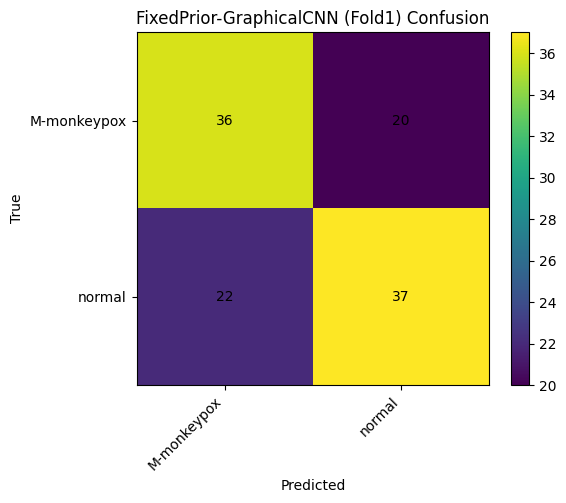

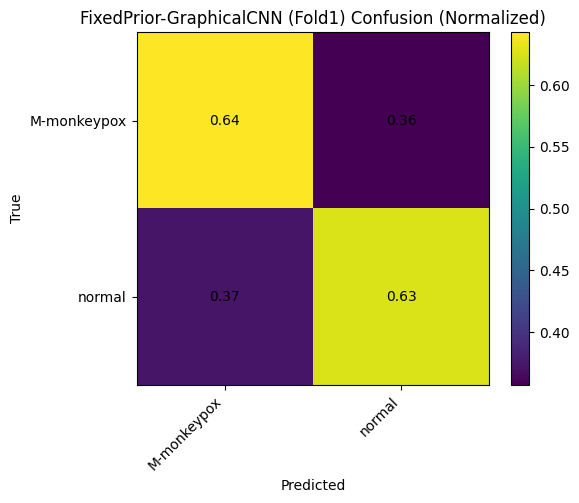

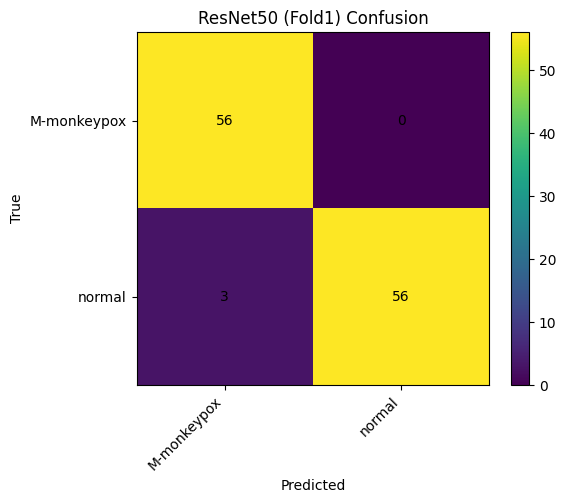

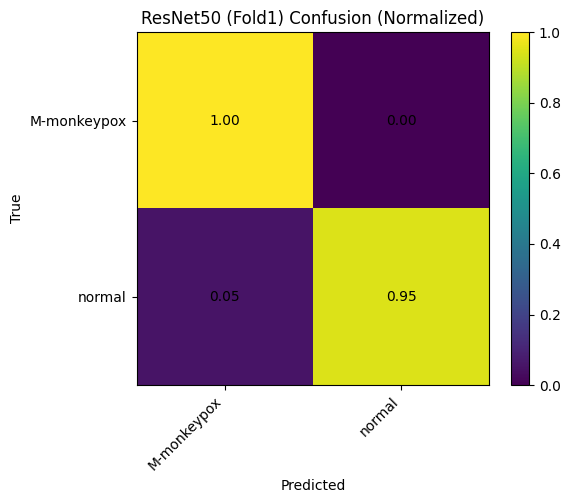

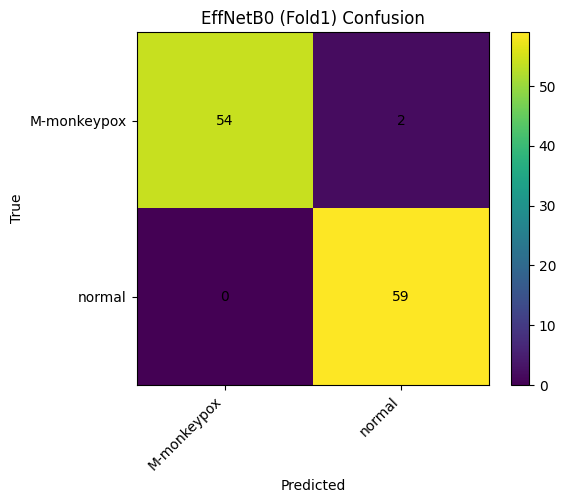

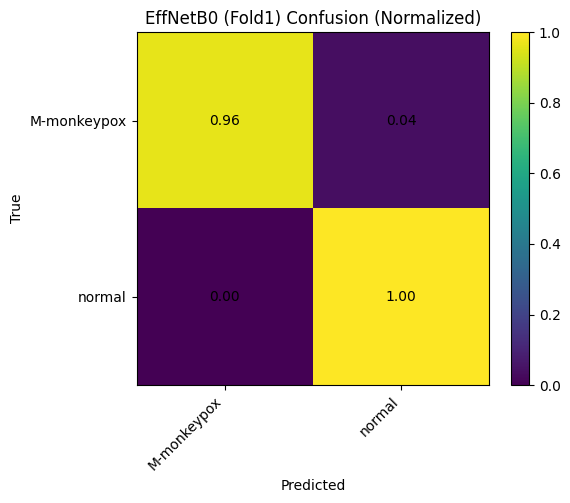

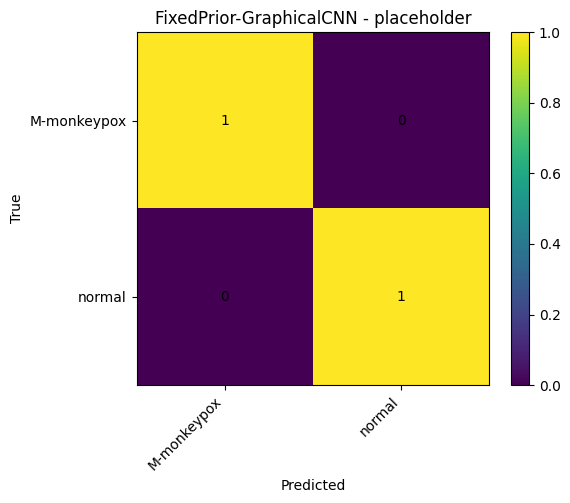

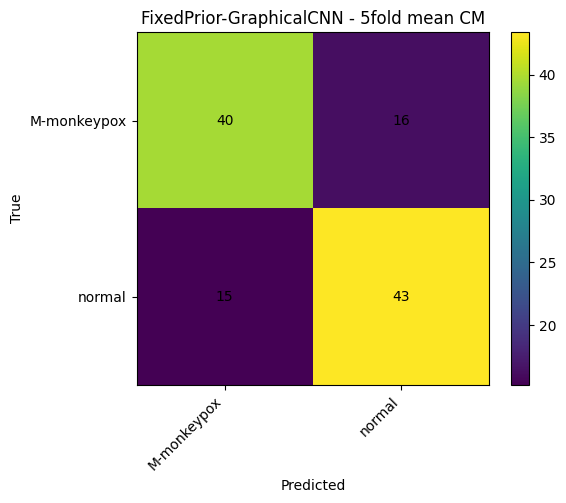

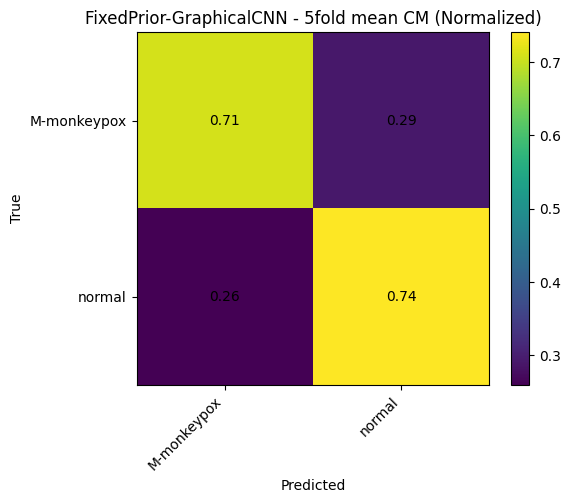


FixedPrior-GraphicalCNN - CM std (raw):


,M-monkeypox,normal
M-monkeypox,4.454212,4.400000
normal,5.268776,5.314132


FixedPrior-GraphicalCNN - CM std (normalized):


,M-monkeypox,normal
M-monkeypox,0.078803,0.078803
normal,0.090105,0.090105


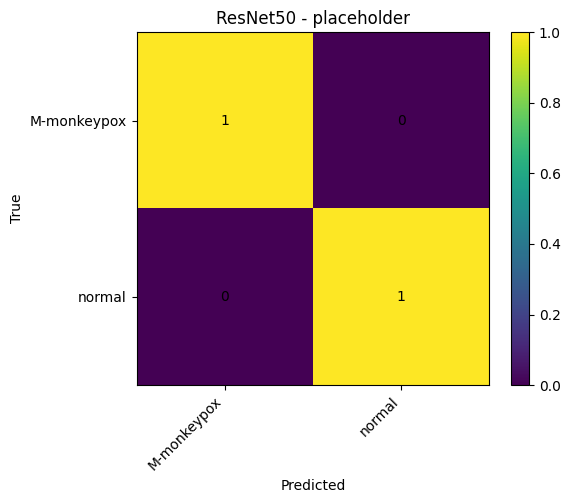

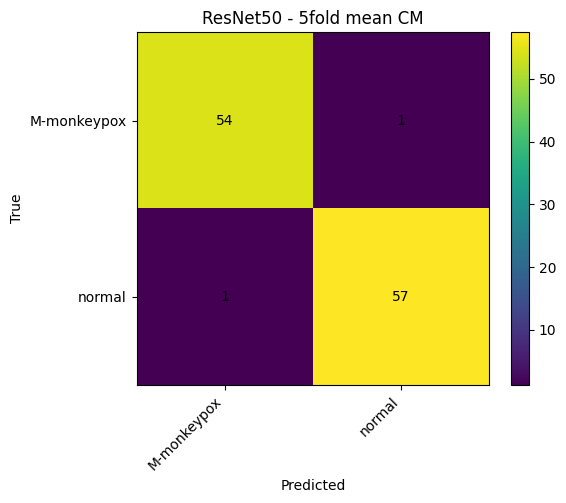

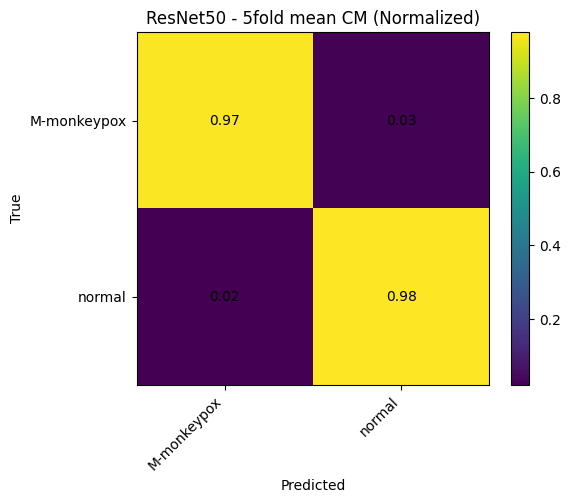


ResNet50 - CM std (raw):


,M-monkeypox,normal
M-monkeypox,1.959592,1.743560
normal,1.166190,1.356466


ResNet50 - CM std (normalized):


,M-monkeypox,normal
M-monkeypox,0.031316,0.031316
normal,0.019837,0.019837


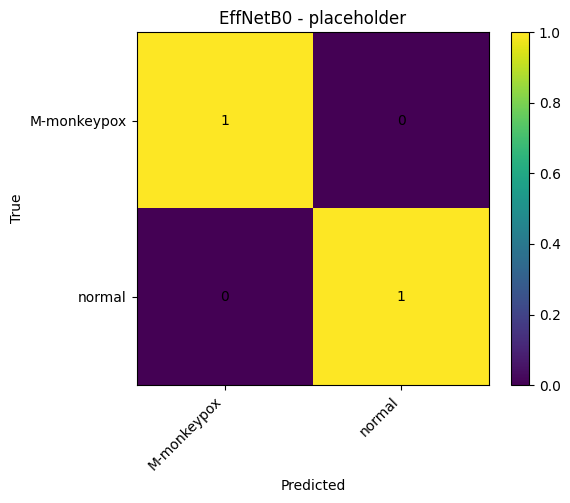

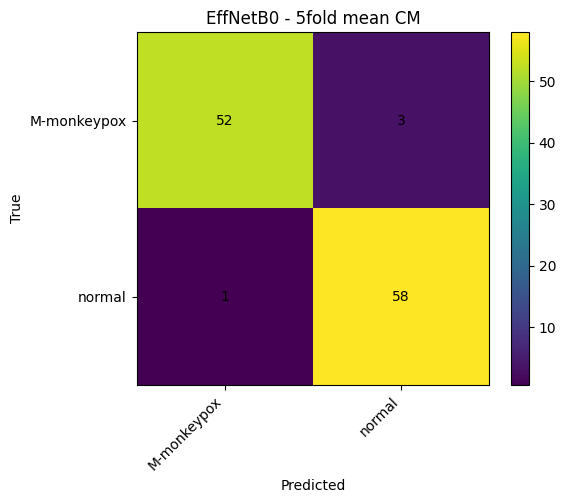

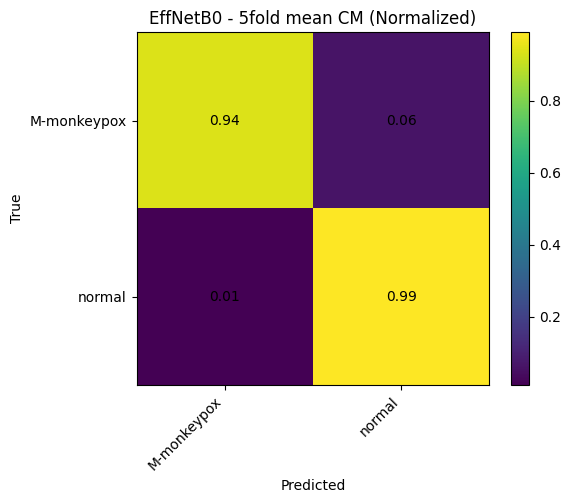


EffNetB0 - CM std (raw):


,M-monkeypox,normal
M-monkeypox,2.332381,1.959592
normal,0.800000,1.264911


EffNetB0 - CM std (normalized):


,M-monkeypox,normal
M-monkeypox,0.035830,0.035830
normal,0.013793,0.013793


,fold,method,val_best_acc,T,epochs_head,epochs_all,acc,prec,rec,f1,auc
0,1,FixedPrior-GraphicalCNN,0.681159,3.714343e-39,0,12,0.634783,0.634906,0.634988,0.634755,0.634988
1,1,ResNet50,0.985507,1.385386e+00,3,12,0.973913,0.974576,0.974576,0.973913,0.996368
2,1,EffNetB0,0.971014,5.970156e-01,3,12,0.982609,0.983607,0.982143,0.982576,0.999697
3,2,FixedPrior-GraphicalCNN,0.811594,7.044976e-01,0,12,0.773913,0.776923,0.772397,0.772520,0.874697
4,2,ResNet50,0.985507,1.264491e+00,3,12,1.000000,1.000000,1.000000,1.000000,1.000000
5,2,EffNetB0,0.956522,1.042772e+00,3,12,0.982609,0.983607,0.982143,0.982576,1.000000
6,3,FixedPrior-GraphicalCNN,0.768116,1.187869e+00,0,12,0.745614,0.758937,0.747537,0.743223,0.853140
7,3,ResNet50,0.985507,1.061487e+00,3,12,0.956140,0.957779,0.955665,0.956056,0.985222
8,3,EffNetB0,0.971014,5.408106e-01,3,12,0.956140,0.957779,0.955665,0.956056,0.992303
9,4,FixedPrior-GraphicalCNN,0.724638,1.577875e+00,0,12,0.736842,0.744246,0.735222,0.733894,0.824200



================= 5-FOLD CV (mean ± std) =================


,method,epochs_head,epochs_all,ACC mean±std,F1 mean±std,AUC mean±std,T mean±std
0,FixedPrior-GraphicalCNN,0,12,0.7256 ± 0.0530,0.7240 ± 0.0522,0.7980 ± 0.0951,0.825 ± 0.596
1,ResNet50,3,12,0.9772 ± 0.0159,0.9772 ± 0.0160,0.9900 ± 0.0113,0.939 ± 0.535
2,EffNetB0,3,12,0.9650 ± 0.0187,0.9648 ± 0.0189,0.9973 ± 0.0031,0.698 ± 0.213


Saved: /content/drive/My Drive/1-a-monkeypox/data2//cv5_methods_results.csv
Saved: /content/drive/My Drive/1-a-monkeypox/data2//cv5_methods_summary.csv


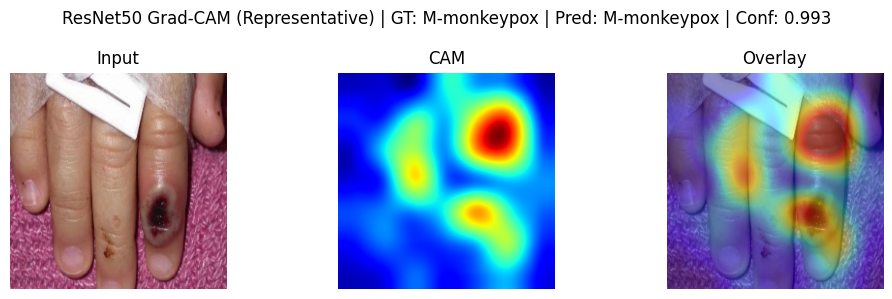

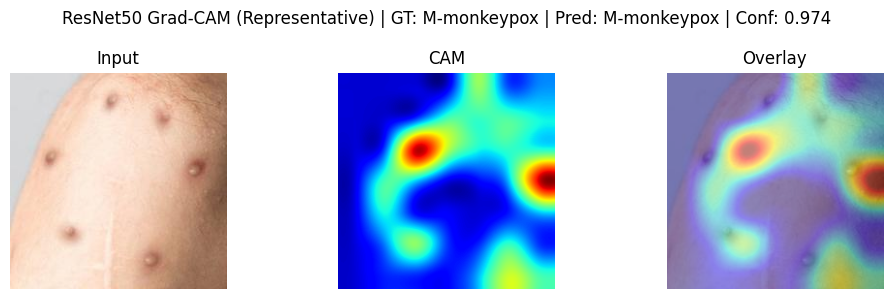

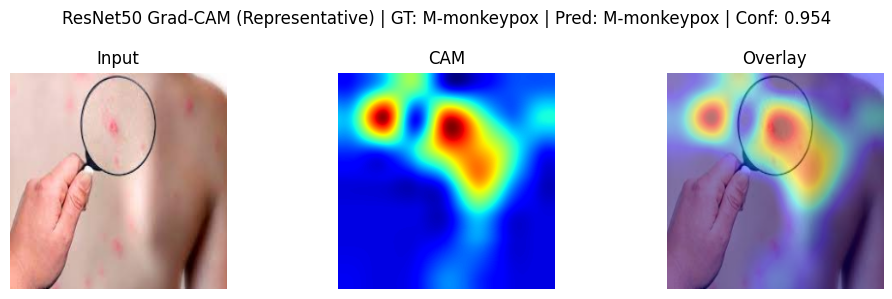

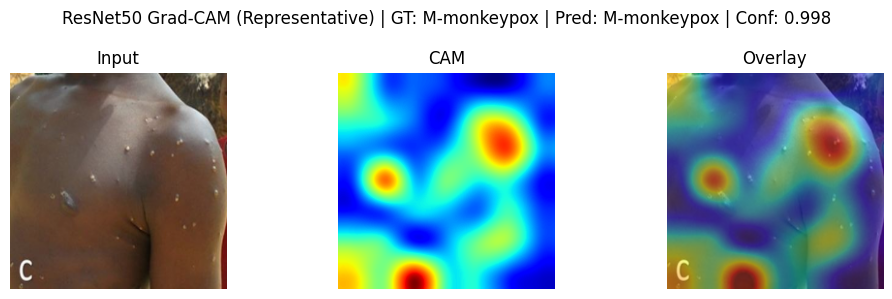

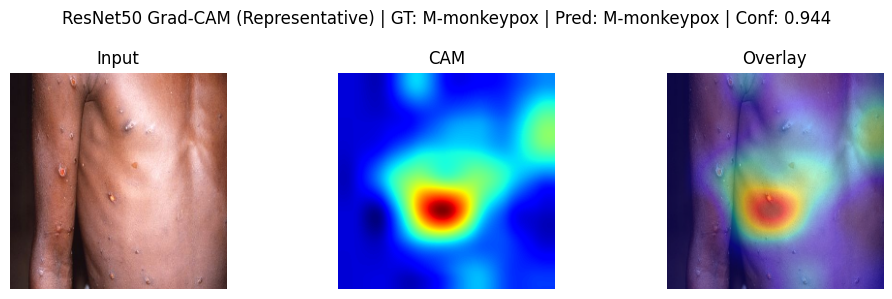

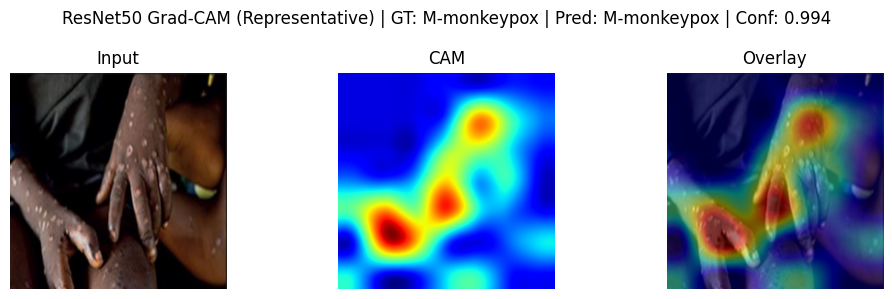

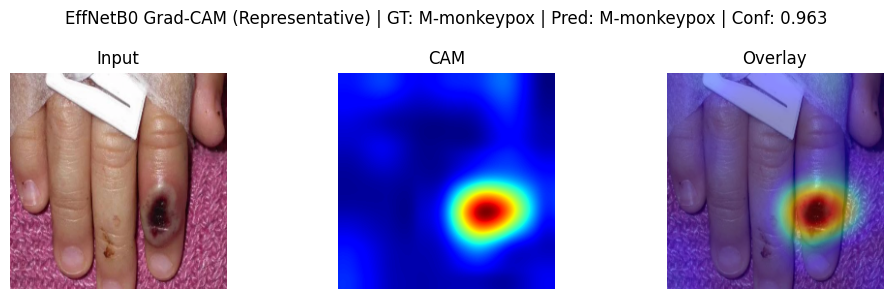

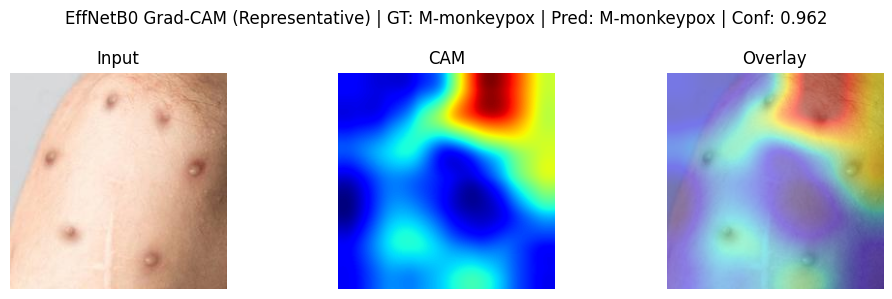

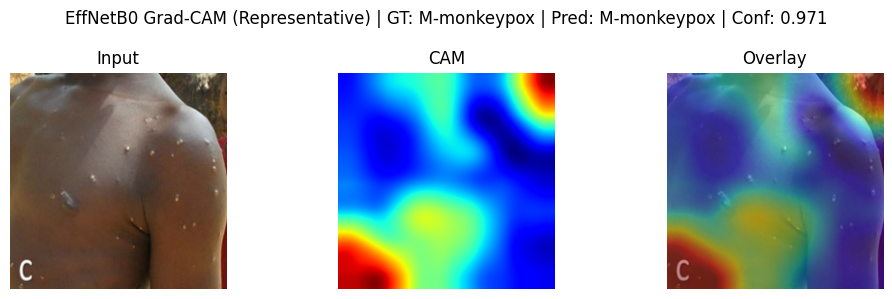

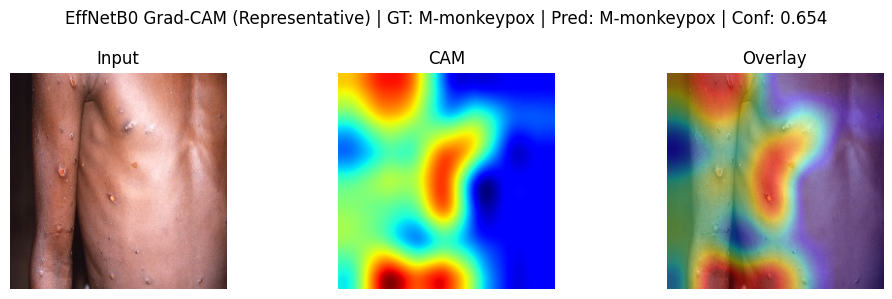

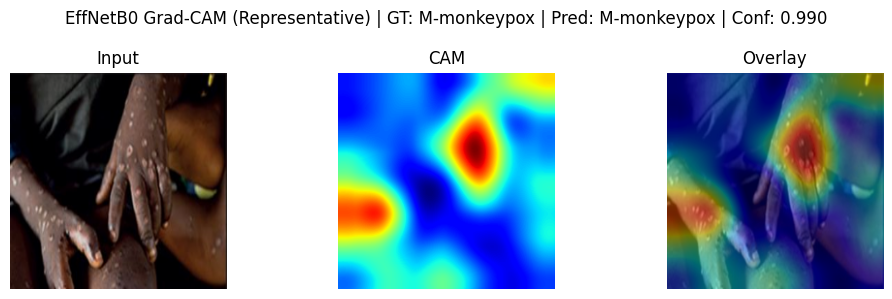

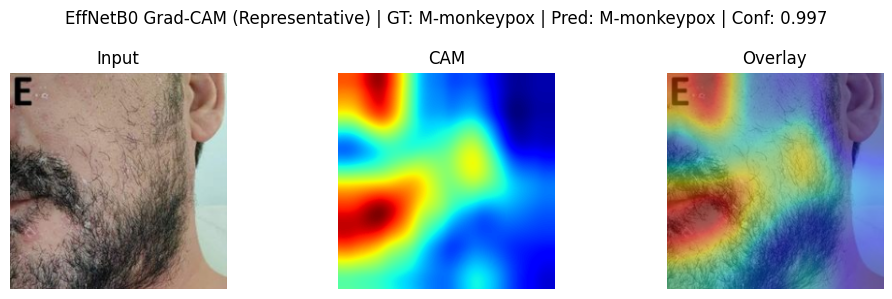

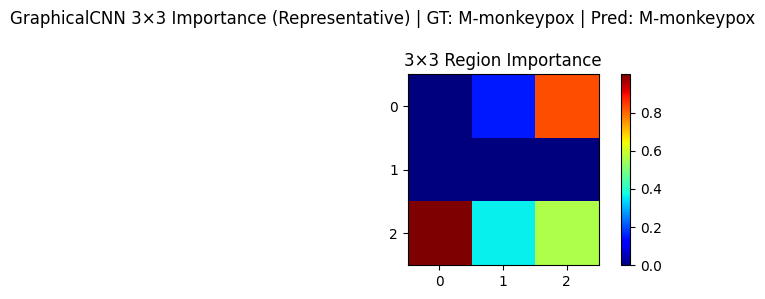

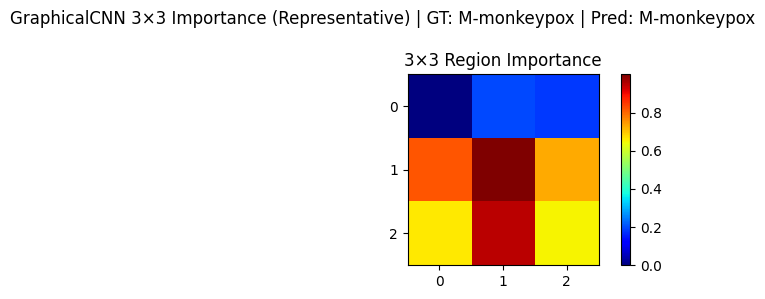

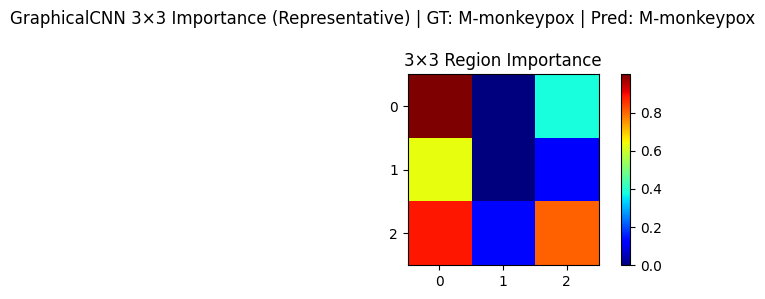

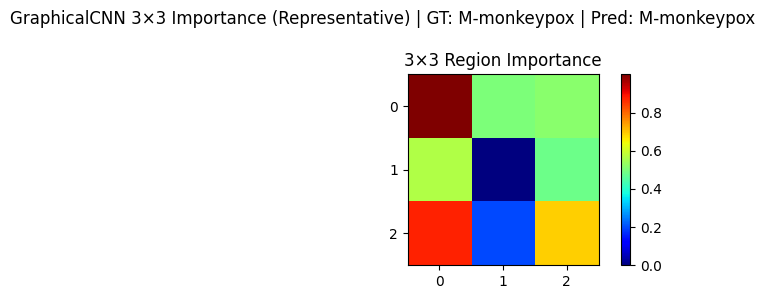

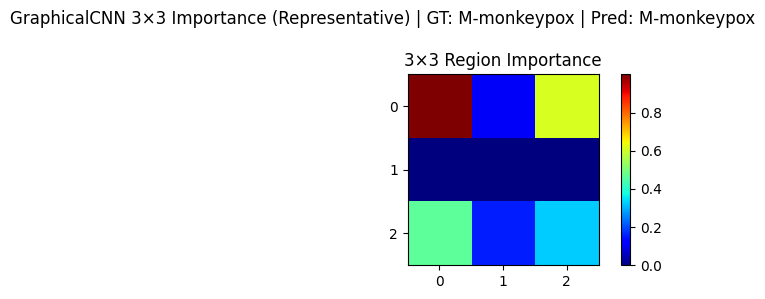

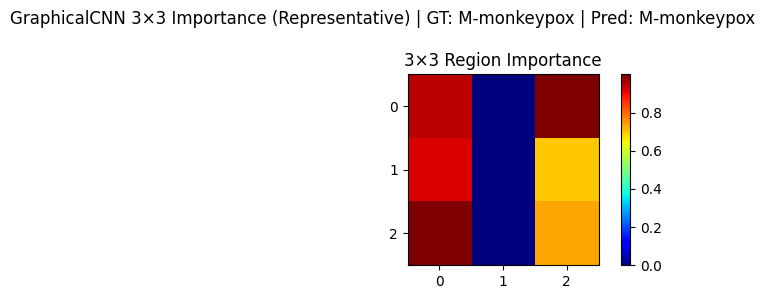

In [ ]:
# ============================================================
# ONE-CELL FINAL (2-class: M-monkeypox vs normal)
# - AUTO CLASS FOLDER MATCH
# - 5-FOLD CV: GraphicalCNN + ResNet50 + EfficientNetB0
# - Fine-tune (epochs_head + epochs_all)
# - ROC (BINARY SAFE: per-class + macro) + Confusion (Fold1 + mean±std)
# - Representative Explainability: Grad-CAM (ResNet/EffNet) + 3×3 importance (GraphicalCNN)
# ============================================================
!pip -q install opencv-python scikit-image scikit-learn tqdm

import os, glob, random
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score, roc_curve, confusion_matrix
from sklearn.preprocessing import label_binarize
from skimage.feature import local_binary_pattern, graycomatrix, graycoprops
import torchvision
from torchvision import transforms
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# =========================
# 0) SETTINGS
# =========================
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# !!! DATA_ROOT'u SEN belirle (örnek):
# DATA_ROOT = "/content/dataset"
# DATA_ROOT = r"C:\...\dataset"
assert "DATA_ROOT" in globals(), "DATA_ROOT tanımlı değil. Örn: DATA_ROOT='/content/dataset'"

CLASSES = ["M-monkeypox", "normal"]
NUM_CLASSES = len(CLASSES)

# =========================
# 1) AUTO CLASS FOLDER RESOLVE
# =========================
def _norm_name(s: str) -> str:
    return s.strip().lower().replace("_","").replace("-","").replace(" ","")

def resolve_class_dirs(root, classes):
    assert os.path.isdir(root), f"DATA_ROOT yok: {root}"
    subdirs = [d for d in os.listdir(root) if os.path.isdir(os.path.join(root,d))]
    print("\n[DEBUG] DATA_ROOT alt klasörleri:")
    for d in sorted(subdirs):
        print(" -", repr(d))

    nmap = {_norm_name(d): d for d in subdirs}
    aliases = {
        "M-monkeypox": ["m-monkeypox","monkeypox","mpox","pox","mmonkeypox","monkey_pox","monkeypoxskin","monkeypoximages"],
        "normal": ["normal","healthy","healthyskin","normalskin","clear","nonmpox"]
    }

    class_dirs = {}
    for c in classes:
        found=None
        key=_norm_name(c)
        if key in nmap:
            found=nmap[key]
        else:
            for a in aliases.get(c, []):
                ak=_norm_name(a)
                if ak in nmap:
                    found=nmap[ak]; break
            if found is None:
                for nk, orig in nmap.items():
                    if key in nk or nk in key:
                        found=orig; break
        class_dirs[c]=found

    missing=[c for c,v in class_dirs.items() if v is None]
    if missing:
        raise AssertionError(f"Sınıf klasörü bulunamadı: {missing}. [DEBUG] listesine göre aliases'i genişlet.")
    return class_dirs

class_dirs = resolve_class_dirs(DATA_ROOT, CLASSES)
print("\nResolved class dirs:", class_dirs)

# =========================
# 2) LIST IMAGES
# =========================
class_to_idx = {c:i for i,c in enumerate(CLASSES)}

def list_images(root):
    paths, labels = [], []
    exts = ("*.jpg","*.jpeg","*.png","*.bmp","*.webp")
    for c in CLASSES:
        cdir = os.path.join(root, class_dirs[c])
        files=[]
        for e in exts:
            files += glob.glob(os.path.join(cdir, e))
        files = sorted(files)
        paths += files
        labels += [class_to_idx[c]] * len(files)
    return np.array(paths), np.array(labels)

paths, labels = list_images(DATA_ROOT)
print("\nTotal images:", len(paths))
assert len(paths) > 0, "Görüntü bulunamadı. DATA_ROOT ya da klasör yapısı hatalı."

print("\n[DEBUG] Class counts:")
for c in CLASSES:
    cdir = os.path.join(DATA_ROOT, class_dirs[c])
    n = sum(len(glob.glob(os.path.join(cdir, e))) for e in ("*.jpg","*.jpeg","*.png","*.bmp","*.webp"))
    print(c, "->", n, "| dir:", cdir)

# ============================================================
# 3) Fixed priors + prior smoothness reg
# ============================================================
def grid_edges(n=3):
    edges=[]
    for r in range(n):
        for c in range(n):
            u=r*n+c
            if r+1<n: edges.append((u,(r+1)*n+c))
            if c+1<n: edges.append((u,r*n+(c+1)))
    return edges

EDGES = grid_edges(3)

def prior_smoothness_loss(feat):  # (B,C,3,3)
    B,C,H,W = feat.shape
    x = feat.view(B,C,H*W)
    loss=0.0
    for u,v in EDGES:
        loss += (x[:,:,u]-x[:,:,v]).pow(2).mean()
    return loss/len(EDGES)

# ============================================================
# 4) Feature extraction (3x3 grid)
# ============================================================
def extract_grid_features(img_rgb, grid=3):
    H,W,_ = img_rgb.shape
    cell = H // grid
    img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

    gx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)
    sob = cv2.magnitude(gx, gy)

    P,R = 8,1
    lbp = local_binary_pattern(gray, P, R, method="uniform")
    lbp_bins = P + 2

    feats=[]
    for i in range(grid):
        row=[]
        for j in range(grid):
            y0,y1 = i*cell, (i+1)*cell if i<grid-1 else H
            x0,x1 = j*cell, (j+1)*cell if j<grid-1 else W
            parts=[]

            p = img_hsv[y0:y1, x0:x1, :].reshape(-1,3).astype(np.float32)
            mean = p.mean(axis=0); std = p.std(axis=0)
            mean[0]/=179.0; std[0]/=179.0
            mean[1:]/=255.0; std[1:]/=255.0
            parts += [mean, std]

            patch_lbp = lbp[y0:y1, x0:x1]
            hist,_ = np.histogram(patch_lbp, bins=np.arange(0, lbp_bins+1), density=False)
            hist = hist.astype(np.float32); hist /= (hist.sum()+1e-6)
            parts += [hist]

            patch_g = gray[y0:y1, x0:x1]
            patch_g = cv2.resize(patch_g, (64,64), interpolation=cv2.INTER_AREA)
            glcm = graycomatrix(patch_g, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)
            props=[]
            for pnm in ["contrast","homogeneity","energy","correlation"]:
                props.append(float(graycoprops(glcm, pnm)[0,0]))
            props = np.array(props, dtype=np.float32)
            props[3] = (props[3]+1.0)/2.0
            parts += [props]

            ps = sob[y0:y1, x0:x1].astype(np.float32)
            e = np.array([ps.mean(), ps.std(), ps.max()], dtype=np.float32)/255.0
            parts += [e]

            row.append(np.concatenate(parts).astype(np.float32))
        feats.append(row)
    return np.array(feats, dtype=np.float32)

Fdim = 6 + 10 + 4 + 3

# ============================================================
# 5) Datasets
# ============================================================
class GraphGridDataset(Dataset):
    def __init__(self, paths, labels, img_size=224, augment=False):
        self.paths=list(paths); self.labels=list(labels)
        self.img_size=img_size; self.augment=augment
    def __len__(self): return len(self.paths)
    def _load_rgb(self, path):
        bgr=cv2.imread(path, cv2.IMREAD_COLOR)
        if bgr is None: raise RuntimeError(f"Cannot read {path}")
        rgb=cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        rgb=cv2.resize(rgb,(self.img_size,self.img_size), interpolation=cv2.INTER_AREA)
        return rgb
    def _augment_rgb(self, rgb):
        if random.random()<0.5: rgb=np.ascontiguousarray(rgb[:, ::-1, :])
        if random.random()<0.15: rgb=np.ascontiguousarray(rgb[::-1, :, :])
        if random.random()<0.25:
            alpha=1.0+random.uniform(-0.12,0.12)
            beta=random.uniform(-10,10)
            rgb=cv2.convertScaleAbs(rgb, alpha=alpha, beta=beta)
        return rgb
    def __getitem__(self, idx):
        rgb=self._load_rgb(self.paths[idx])
        if self.augment: rgb=self._augment_rgb(rgb)
        feats=extract_grid_features(rgb, grid=3)
        x=torch.from_numpy(feats).permute(2,0,1).float()  # (C,3,3)
        y=torch.tensor(int(self.labels[idx]), dtype=torch.long)
        return x,y

class ImageDataset(Dataset):
    def __init__(self, paths, labels, train=False, img_size=224):
        self.paths=list(paths); self.labels=list(labels)
        self.train=train; self.img_size=img_size
        self.tf = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((img_size,img_size)),
            transforms.RandomHorizontalFlip(p=0.5) if train else transforms.Lambda(lambda x:x),
            transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10, hue=0.02) if train else transforms.Lambda(lambda x:x),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
        ])
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        bgr=cv2.imread(self.paths[idx], cv2.IMREAD_COLOR)
        if bgr is None: raise RuntimeError(f"Cannot read {self.paths[idx]}")
        rgb=cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        rgb=cv2.resize(rgb,(self.img_size,self.img_size), interpolation=cv2.INTER_AREA)
        x=self.tf(rgb)
        y=torch.tensor(int(self.labels[idx]), dtype=torch.long)
        return x,y

# ============================================================
# 6) Models
# ============================================================
class GraphicalCNN(nn.Module):
    def __init__(self, in_ch, num_classes, dropout=0.25):
        super().__init__()
        self.conv1=nn.Conv2d(in_ch,64,3,padding=1); self.bn1=nn.BatchNorm2d(64)
        self.conv2=nn.Conv2d(64,128,3,padding=1); self.bn2=nn.BatchNorm2d(128)
        self.pool=nn.AdaptiveAvgPool2d((1,1))
        self.fc1=nn.Linear(128,64); self.drop=nn.Dropout(dropout)
        self.fc2=nn.Linear(64,num_classes)
    def forward(self,x):
        x=F.relu(self.bn1(self.conv1(x)))
        x=F.relu(self.bn2(self.conv2(x)))
        feat=x
        x=self.pool(x).flatten(1)
        x=F.relu(self.fc1(x))
        x=self.drop(x)
        logits=self.fc2(x)
        return logits, feat

def build_resnet50(num_classes):
    m=torchvision.models.resnet50(weights=torchvision.models.ResNet50_Weights.IMAGENET1K_V2)
    m.fc=nn.Linear(m.fc.in_features, num_classes)
    return m

def build_efficientnet_b0(num_classes):
    m=torchvision.models.efficientnet_b0(weights=torchvision.models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    m.classifier[1]=nn.Linear(m.classifier[1].in_features, num_classes)
    return m

# ============================================================
# 7) Metrics + utilities
# ============================================================
def compute_metrics(y_true, y_pred, y_prob):
    y_true=np.asarray(y_true); y_pred=np.asarray(y_pred); y_prob=np.asarray(y_prob)
    acc=accuracy_score(y_true,y_pred)
    prec,rec,f1,_=precision_recall_fscore_support(y_true,y_pred,average="macro",zero_division=0)

    auc=float("nan")
    try:
        if y_prob.ndim == 1:
            auc = roc_auc_score(y_true, y_prob)
        elif y_prob.shape[1] == 2:
            auc = roc_auc_score(y_true, y_prob[:,1])
        else:
            auc = roc_auc_score(y_true, y_prob, multi_class="ovr")
    except:
        pass

    return {"acc":float(acc),"prec":float(prec),"rec":float(rec),"f1":float(f1),"auc":float(auc)}

@torch.no_grad()
def predict_probs(model, loader, is_graphical):
    model.eval()
    probs_all=[]; y_all=[]
    for x,y in loader:
        x=x.to(device); y=y.to(device)
        if is_graphical: logits,_=model(x)
        else: logits=model(x)
        probs_all.append(F.softmax(logits,dim=1).cpu().numpy())
        y_all.append(y.cpu().numpy())
    probs_all=np.concatenate(probs_all,axis=0)
    y_all=np.concatenate(y_all,axis=0)
    pred=probs_all.argmax(axis=1)
    return y_all,pred,probs_all

def run_epoch_train(model, loader, optimizer, is_graphical, lambda_prior=0.0):
    model.train(True)
    crit=nn.CrossEntropyLoss()
    total=0.0
    for x,y in loader:
        x=x.to(device); y=y.to(device)
        optimizer.zero_grad(set_to_none=True)
        if is_graphical:
            logits,feat=model(x)
            ce=crit(logits,y)
            lp=prior_smoothness_loss(feat) if lambda_prior>0 else 0.0
            loss=ce + (lambda_prior*lp if lambda_prior>0 else 0.0)
        else:
            logits=model(x)
            loss=crit(logits,y)
        loss.backward()
        optimizer.step()
        total += float(loss.item())*x.size(0)
    return total/len(loader.dataset)

@torch.no_grad()
def eval_loss(model, loader, is_graphical):
    model.eval()
    crit=nn.CrossEntropyLoss()
    total=0.0
    for x,y in loader:
        x=x.to(device); y=y.to(device)
        if is_graphical: logits,_=model(x)
        else: logits=model(x)
        total += float(crit(logits,y).item())*x.size(0)
    return total/len(loader.dataset)

class TemperatureScaler(nn.Module):
    def __init__(self):
        super().__init__()
        self.log_t=nn.Parameter(torch.zeros(1))
    def forward(self, logits):
        T=torch.exp(self.log_t)+1e-6
        return logits/T

def fit_temperature_on_val(model, val_loader, is_graphical, max_iter=200):
    model.eval()
    ts=TemperatureScaler().to(device)
    logits_list=[]; y_list=[]
    with torch.no_grad():
        for x,y in val_loader:
            x=x.to(device); y=y.to(device)
            if is_graphical: logits,_=model(x)
            else: logits=model(x)
            logits_list.append(logits); y_list.append(y)
    logits_all=torch.cat(logits_list,dim=0)
    y_all=torch.cat(y_list,dim=0)

    opt=torch.optim.LBFGS(ts.parameters(), lr=0.1, max_iter=max_iter)
    def closure():
        opt.zero_grad(set_to_none=True)
        loss=F.cross_entropy(ts(logits_all), y_all)
        loss.backward()
        return loss
    opt.step(closure)
    T=float(torch.exp(ts.log_t).detach().cpu().item())
    return ts, T

@torch.no_grad()
def calibrated_test_probs(model, ts, test_loader, is_graphical):
    model.eval()
    probs=[]
    for x,y in test_loader:
        x=x.to(device)
        if is_graphical: logits,_=model(x)
        else: logits=model(x)
        logits=ts(logits)
        probs.append(F.softmax(logits,dim=1).cpu().numpy())
    return np.concatenate(probs,axis=0)

# -------------------------
# ROC + CM (BINARY SAFE)
# -------------------------
def _ensure_prob_2d(y_prob, num_classes):
    y_prob = np.asarray(y_prob)
    if y_prob.ndim == 1:
        y_prob = y_prob.reshape(-1, 1)
    if num_classes == 2 and y_prob.shape[1] == 1:
        p1 = y_prob[:, 0]
        y_prob = np.stack([1 - p1, p1], axis=1)
    return y_prob

def plot_roc_per_class_and_macro_safe(y_true, y_prob, class_names, title):
    y_true = np.asarray(y_true).astype(int)
    K = len(class_names)
    y_prob = _ensure_prob_2d(y_prob, K)

    Y = label_binarize(y_true, classes=list(range(K)))
    if K == 2 and Y.shape[1] == 1:
        Y = np.hstack([1 - Y, Y])

    plt.figure()
    fprs=[]; tprs=[]
    for k in range(K):
        fpr, tpr, _ = roc_curve(Y[:, k], y_prob[:, k])
        plt.plot(fpr, tpr, label=class_names[k])
        fprs.append(fpr); tprs.append(tpr)

    all_fpr = np.unique(np.concatenate(fprs))
    mean_tpr = np.zeros_like(all_fpr)
    for k in range(K):
        mean_tpr += np.interp(all_fpr, fprs[k], tprs[k])
    mean_tpr /= K

    plt.plot(all_fpr, mean_tpr, linestyle="--", label="Macro-average")
    plt.plot([0,1],[0,1], linestyle=":")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title + " (Per-class + Macro ROC)")
    plt.legend()
    plt.show()

    try:
        auc_pos = roc_auc_score(y_true, y_prob[:,1])
        print(f"{title} | AUC(pos={class_names[1]}): {auc_pos:.4f}")
    except:
        pass

def plot_confusion_from_preds(y_true, y_pred, class_names, title, normalize=False):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    K = len(class_names)
    cmx = confusion_matrix(y_true, y_pred, labels=list(range(K))).astype(np.float32)
    if normalize:
        cmx = cmx / (cmx.sum(axis=1, keepdims=True) + 1e-9)

    plt.figure(figsize=(6,5))
    plt.imshow(cmx, interpolation="nearest")
    plt.title(title + (" (Normalized)" if normalize else ""))
    plt.colorbar()
    ticks = np.arange(K)
    plt.xticks(ticks, class_names, rotation=45, ha="right")
    plt.yticks(ticks, class_names)
    plt.xlabel("Predicted"); plt.ylabel("True")

    for i in range(K):
        for j in range(K):
            val = cmx[i, j]
            txt = f"{val:.2f}" if normalize else f"{int(val)}"
            plt.text(j, i, txt, ha="center", va="center")
    plt.tight_layout()
    plt.show()
    return cmx

def plot_history(hist, title):
    plt.figure()
    plt.plot(hist["train_loss"]); plt.plot(hist["val_loss"])
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title(f"{title} - Loss")
    plt.legend(["train","val"]); plt.show()
    plt.figure()
    plt.plot(hist["val_acc"])
    plt.xlabel("Epoch"); plt.ylabel("Val Accuracy"); plt.title(f"{title} - Val Acc")
    plt.show()

# ============================================================
# 8) Fine-tuning (epoch sayısı dahil)
# ============================================================
def set_requires_grad(module, flag: bool):
    for p in module.parameters():
        p.requires_grad = flag

def freeze_backbone_resnet(m):
    set_requires_grad(m, False)
    set_requires_grad(m.fc, True)

def freeze_backbone_effnet(m):
    set_requires_grad(m, False)
    set_requires_grad(m.classifier, True)

def make_optimizer(model, lr, wd):
    params = [p for p in model.parameters() if p.requires_grad]
    return torch.optim.AdamW(params, lr=lr, weight_decay=wd)

def train_with_early_stopping_finetune(
    build_fn,
    train_loader, val_loader,
    is_graphical,
    epochs_head=3,          # head fine-tune epoch
    epochs_all=12,          # full fine-tune epoch
    lr_head=1e-3,
    lr_all=3e-4,
    wd=1e-4,
    patience=4,
    lambda_prior=0.0,
    freeze_backbone_fn=None
):
    model = build_fn().to(device)

    history = {"train_loss":[], "val_loss":[], "val_acc":[], "lr":[]}
    best=-1.0; best_state=None; bad=0

    def run_train_val(opt, sched, n_epochs):
        nonlocal best, best_state, bad
        for ep in range(1, n_epochs+1):
            tr_loss = run_epoch_train(model, train_loader, opt, is_graphical, lambda_prior=lambda_prior)
            va_loss = eval_loss(model, val_loader, is_graphical)
            yv,pv,probv = predict_probs(model, val_loader, is_graphical)
            mval = compute_metrics(yv,pv,probv)

            history["train_loss"].append(tr_loss)
            history["val_loss"].append(va_loss)
            history["val_acc"].append(mval["acc"])
            history["lr"].append(opt.param_groups[0]["lr"])
            sched.step(mval["acc"])

            if mval["acc"] > best + 1e-4:
                best = mval["acc"]
                best_state = {k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
                bad = 0
            else:
                bad += 1
                if bad >= patience:
                    return

    # GraphicalCNN: direkt full train
    if is_graphical or freeze_backbone_fn is None:
        opt = torch.optim.AdamW(model.parameters(), lr=lr_all, weight_decay=wd)
        sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="max", factor=0.5, patience=2)
        run_train_val(opt, sched, epochs_all)
        model.load_state_dict(best_state); model.to(device)
        return model, best, history

    # Phase-1: head train (backbone frozen)
    freeze_backbone_fn(model)
    opt = make_optimizer(model, lr_head, wd)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="max", factor=0.5, patience=2)
    run_train_val(opt, sched, epochs_head)

    # Phase-2: full fine-tune
    set_requires_grad(model, True)
    opt = torch.optim.AdamW(model.parameters(), lr=lr_all, weight_decay=wd)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="max", factor=0.5, patience=2)
    run_train_val(opt, sched, epochs_all)

    model.load_state_dict(best_state); model.to(device)
    return model, best, history

# ============================================================
# 9) Explainability
# ============================================================
def denormalize_img(tensor, mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]):
    x = tensor.detach().cpu().clone()
    for c in range(3):
        x[c] = x[c]*std[c] + mean[c]
    x = torch.clamp(x, 0, 1)  # clamp
    x = (x.permute(1,2,0).numpy() * 255).astype(np.uint8)
    return x

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self.hook_a = target_layer.register_forward_hook(self._forward_hook)
        self.hook_g = target_layer.register_full_backward_hook(self._backward_hook)

    def _forward_hook(self, module, inp, out):
        self.activations = out

    def _backward_hook(self, module, grad_in, grad_out):
        self.gradients = grad_out[0]

    def remove(self):
        self.hook_a.remove()
        self.hook_g.remove()

    def __call__(self, x, class_idx=None):
        self.model.zero_grad(set_to_none=True)
        logits = self.model(x)
        if class_idx is None:
            class_idx = int(torch.argmax(logits, dim=1).item())
        score = logits[:, class_idx].sum()
        score.backward(retain_graph=True)

        A  = self.activations
        dA = self.gradients
        w = dA.mean(dim=(2,3), keepdim=True)
        cam_map = (w * A).sum(dim=1, keepdim=True)
        cam_map = F.relu(cam_map)
        cam_map = cam_map - cam_map.min()
        cam_map = cam_map / (cam_map.max() + 1e-8)
        return cam_map.detach(), logits.detach()

def overlay_cam(rgb_uint8, cam_2d, alpha=0.45):
    heat = (cm.jet(cam_2d)[:,:,:3] * 255).astype(np.uint8)
    out = (alpha*heat + (1-alpha)*rgb_uint8).astype(np.uint8)
    return out

@torch.no_grad()
def _predict_labels(model, xb, is_graphical=False):
    if is_graphical:
        logits, _ = model(xb)
    else:
        logits = model(xb)
    return logits.argmax(dim=1)

def show_gradcam_examples(model, target_layer, loader, class_names, max_show=6, title="Grad-CAM"):
    model.eval()
    gc = GradCAM(model, target_layer)
    shown = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        pred = _predict_labels(model, xb, is_graphical=False)

        for i in range(xb.size(0)):
            if shown >= max_show:
                gc.remove()
                return
            if int(pred[i].item()) != int(yb[i].item()):
                continue

            x1 = xb[i:i+1].clone().requires_grad_(True)
            cam_map, logits = gc(x1, class_idx=int(pred[i].item()))
            cam_map = cam_map.cpu().squeeze().numpy()
            cam_up = cv2.resize(cam_map, (x1.shape[-1], x1.shape[-2]), interpolation=cv2.INTER_CUBIC)

            rgb = denormalize_img(x1.squeeze(0))
            over = overlay_cam(rgb, cam_up)

            gt = class_names[int(yb[i].item())]
            pr = class_names[int(pred[i].item())]
            conf = float(F.softmax(logits, dim=1)[0, int(pred[i].item())].detach().cpu().item())

            plt.figure(figsize=(10,3))
            plt.suptitle(f"{title} | GT: {gt} | Pred: {pr} | Conf: {conf:.3f}")
            plt.subplot(1,3,1); plt.imshow(rgb); plt.axis("off"); plt.title("Input")
            plt.subplot(1,3,2); plt.imshow(cam_up, cmap="jet"); plt.axis("off"); plt.title("CAM")
            plt.subplot(1,3,3); plt.imshow(over); plt.axis("off"); plt.title("Overlay")
            plt.tight_layout()
            plt.show()

            shown += 1

def show_graphicalcnn_grid_heatmap(g_model, loader, class_names, max_show=6, title="GraphicalCNN 3×3 Importance"):
    g_model.eval()
    shown = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        xb_req = xb.clone().requires_grad_(True)
        logits, feat = g_model(xb_req)          # feat: (B,128,3,3)
        feat.retain_grad()                     # IMPORTANT for feat.grad
        pred = logits.argmax(dim=1)

        for i in range(xb.size(0)):
            if shown >= max_show:
                return
            if int(pred[i].item()) != int(yb[i].item()):
                continue

            g_model.zero_grad(set_to_none=True)
            cls = int(pred[i].item())
            score = logits[i, cls]
            score.backward(retain_graph=True)

            grad = feat.grad[i]                 # (128,3,3)
            act  = feat.detach()[i]             # (128,3,3)
            w = grad.mean(dim=(1,2), keepdim=True)
            cam_grid = (w * act).sum(dim=0)     # (3,3)
            cam_grid = F.relu(cam_grid)
            cam_grid = cam_grid - cam_grid.min()
            cam_grid = cam_grid / (cam_grid.max() + 1e-8)
            cam_grid = cam_grid.detach().cpu().numpy()

            gt = class_names[int(yb[i].item())]
            pr = class_names[int(pred[i].item())]

            plt.figure(figsize=(6,3))
            plt.suptitle(f"{title} | GT: {gt} | Pred: {pr}")
            plt.imshow(cam_grid, cmap="jet", interpolation="nearest")
            plt.xticks([0,1,2]); plt.yticks([0,1,2])
            plt.title("3×3 Region Importance")
            plt.colorbar(fraction=0.046, pad=0.04)
            plt.tight_layout()
            plt.show()

            shown += 1

# ============================================================
# 10) 5-Fold CV
# ============================================================
lambda_prior = 0.15

# Fine-tune epoch sayıları (makalede raporlayacağın kısım)
epochs_head = 3
epochs_all  = 12

# LR'lar
lr_graph    = 1e-3
lr_head     = 1e-3
lr_all      = 3e-4

batch_size = 64
val_ratio  = 0.15

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

rows=[]
fold1_hists={}
fold1_rocs={}
fold_preds = {"FixedPrior-GraphicalCNN": [], "ResNet50": [], "EffNetB0": []}

# Son fold modelleri (explainability için)
g_model = rn_model = en_model = None
dl_te_i = dl_te_g = None

for fold, (trainval_idx, test_idx) in enumerate(skf.split(paths, labels), 1):
    p_trainval, y_trainval = paths[trainval_idx], labels[trainval_idx]
    p_test, y_test         = paths[test_idx], labels[test_idx]

    sss = StratifiedShuffleSplit(n_splits=1, test_size=val_ratio, random_state=SEED+fold)
    tr_idx, va_idx = next(sss.split(p_trainval, y_trainval))
    p_tr, y_tr = p_trainval[tr_idx], y_trainval[tr_idx]
    p_va, y_va = p_trainval[va_idx], y_trainval[va_idx]

    print(f"\n===== Fold {fold}/5 | train {len(p_tr)} | val {len(p_va)} | test {len(p_test)} =====")

    dl_tr_g = DataLoader(GraphGridDataset(p_tr,y_tr,augment=True),  batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
    dl_va_g = DataLoader(GraphGridDataset(p_va,y_va,augment=False), batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    dl_te_g = DataLoader(GraphGridDataset(p_test,y_test,augment=False), batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    dl_tr_i = DataLoader(ImageDataset(p_tr,y_tr,train=True),   batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
    dl_va_i = DataLoader(ImageDataset(p_va,y_va,train=False),  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    dl_te_i = DataLoader(ImageDataset(p_test,y_test,train=False), batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    # A) GraphicalCNN
    def build_graph(): return GraphicalCNN(in_ch=Fdim, num_classes=NUM_CLASSES, dropout=0.25)
    g_model, g_best, g_hist = train_with_early_stopping_finetune(
        build_graph, dl_tr_g, dl_va_g, True,
        epochs_all=epochs_all, lr_all=lr_graph, wd=1e-4, patience=4, lambda_prior=lambda_prior
    )
    ts_g, Tg = fit_temperature_on_val(g_model, dl_va_g, True)
    prob_cal_g = calibrated_test_probs(g_model, ts_g, dl_te_g, True)
    pred_cal_g = prob_cal_g.argmax(axis=1)
    m_g = compute_metrics(y_test, pred_cal_g, prob_cal_g)
    rows.append({"fold":fold, "method":"FixedPrior-GraphicalCNN", "val_best_acc":g_best, "T":Tg,
                 "epochs_head":0, "epochs_all":epochs_all, **m_g})
    fold_preds["FixedPrior-GraphicalCNN"].append((y_test.copy(), pred_cal_g.copy()))

    # B) ResNet50 (head + full fine-tune)
    def build_rn(): return build_resnet50(num_classes=NUM_CLASSES)
    rn_model, rn_best, rn_hist = train_with_early_stopping_finetune(
        build_rn, dl_tr_i, dl_va_i, False,
        epochs_head=epochs_head, epochs_all=epochs_all,
        lr_head=lr_head, lr_all=lr_all, wd=1e-4, patience=4,
        freeze_backbone_fn=freeze_backbone_resnet
    )
    ts_rn, Trn = fit_temperature_on_val(rn_model, dl_va_i, False)
    prob_cal_rn = calibrated_test_probs(rn_model, ts_rn, dl_te_i, False)
    pred_cal_rn = prob_cal_rn.argmax(axis=1)
    m_rn = compute_metrics(y_test, pred_cal_rn, prob_cal_rn)
    rows.append({"fold":fold, "method":"ResNet50", "val_best_acc":rn_best, "T":Trn,
                 "epochs_head":epochs_head, "epochs_all":epochs_all, **m_rn})
    fold_preds["ResNet50"].append((y_test.copy(), pred_cal_rn.copy()))

    # C) EffNetB0 (head + full fine-tune)
    def build_en(): return build_efficientnet_b0(num_classes=NUM_CLASSES)
    en_model, en_best, en_hist = train_with_early_stopping_finetune(
        build_en, dl_tr_i, dl_va_i, False,
        epochs_head=epochs_head, epochs_all=epochs_all,
        lr_head=lr_head, lr_all=lr_all, wd=1e-4, patience=4,
        freeze_backbone_fn=freeze_backbone_effnet
    )
    ts_en, Ten = fit_temperature_on_val(en_model, dl_va_i, False)
    prob_cal_en = calibrated_test_probs(en_model, ts_en, dl_te_i, False)
    pred_cal_en = prob_cal_en.argmax(axis=1)
    m_en = compute_metrics(y_test, pred_cal_en, prob_cal_en)
    rows.append({"fold":fold, "method":"EffNetB0", "val_best_acc":en_best, "T":Ten,
                 "epochs_head":epochs_head, "epochs_all":epochs_all, **m_en})
    fold_preds["EffNetB0"].append((y_test.copy(), pred_cal_en.copy()))

    if fold == 1:
        fold1_hists = {"FixedPrior-GraphicalCNN": g_hist, "ResNet50": rn_hist, "EffNetB0": en_hist}
        fold1_rocs  = {
            "FixedPrior-GraphicalCNN": (y_test, prob_cal_g),
            "ResNet50": (y_test, prob_cal_rn),
            "EffNetB0": (y_test, prob_cal_en),
        }

# ============================================================
# 11) Plots (Fold-1): History + ROC + CM
# ============================================================
for name, hist in fold1_hists.items():
    plot_history(hist, f"{name} (Fold1)")

for name, (yt, yp) in fold1_rocs.items():
    plot_roc_per_class_and_macro_safe(yt, yp, CLASSES, f"{name} (Fold1)")

for name, (yt, yp) in fold1_rocs.items():
    yp2 = _ensure_prob_2d(yp, NUM_CLASSES)
    y_pred = yp2.argmax(axis=1)
    plot_confusion_from_preds(yt, y_pred, CLASSES, f"{name} (Fold1) Confusion", normalize=False)
    plot_confusion_from_preds(yt, y_pred, CLASSES, f"{name} (Fold1) Confusion", normalize=True)

# ============================================================
# 12) mean±std CM over folds (per method)
# ============================================================
for method in fold_preds.keys():
    cms=[]; cms_n=[]
    for (yt, ypred) in fold_preds[method]:
        cmx = confusion_matrix(yt, ypred, labels=list(range(NUM_CLASSES))).astype(np.float32)
        cms.append(cmx)
        cmn = cmx / (cmx.sum(axis=1, keepdims=True) + 1e-9)
        cms_n.append(cmn)

    cms = np.stack(cms, axis=0)
    cms_n = np.stack(cms_n, axis=0)

    cm_mean, cm_std = cms.mean(axis=0), cms.std(axis=0)
    cmn_mean, cmn_std = cms_n.mean(axis=0), cms_n.std(axis=0)

    # plot mean CM
    plot_confusion_from_preds([0,1],[0,1],CLASSES,f"{method} - placeholder")  # create fig style once
    plt.close("all")
    # draw with our helper by directly reusing plotting code:
    def _plot_cm_matrix(mat, title, normalize=False):
        plt.figure(figsize=(6,5))
        plt.imshow(mat, interpolation="nearest")
        plt.title(title + (" (Normalized)" if normalize else ""))
        plt.colorbar()
        ticks = np.arange(NUM_CLASSES)
        plt.xticks(ticks, CLASSES, rotation=45, ha="right")
        plt.yticks(ticks, CLASSES)
        plt.xlabel("Predicted"); plt.ylabel("True")
        for i in range(NUM_CLASSES):
            for j in range(NUM_CLASSES):
                val = mat[i, j]
                txt = f"{val:.2f}" if normalize else f"{int(round(val))}"
                plt.text(j, i, txt, ha="center", va="center")
        plt.tight_layout()
        plt.show()

    _plot_cm_matrix(cm_mean, f"{method} - 5fold mean CM", normalize=False)
    _plot_cm_matrix(cmn_mean, f"{method} - 5fold mean CM", normalize=True)

    print(f"\n{method} - CM std (raw):")
    display(pd.DataFrame(cm_std, index=CLASSES, columns=CLASSES))
    print(f"{method} - CM std (normalized):")
    display(pd.DataFrame(cmn_std, index=CLASSES, columns=CLASSES))

# ============================================================
# 13) Tables + Save
# ============================================================
df = pd.DataFrame(rows)
display(df)

def mean_std_table(df):
    out=[]
    for m in df["method"].unique():
        d = df[df["method"]==m]
        out.append({
            "method": m,
            "epochs_head": int(d["epochs_head"].iloc[0]),
            "epochs_all":  int(d["epochs_all"].iloc[0]),
            "ACC mean±std": f"{d['acc'].mean():.4f} ± {d['acc'].std():.4f}",
            "F1  mean±std": f"{d['f1'].mean():.4f} ± {d['f1'].std():.4f}",
            "AUC mean±std": f"{d['auc'].mean():.4f} ± {d['auc'].std():.4f}",
            "T   mean±std": f"{d['T'].mean():.3f} ± {d['T'].std():.3f}",
        })
    return pd.DataFrame(out)

summary = mean_std_table(df)
print("\n================= 5-FOLD CV (mean ± std) =================")
display(summary)

OUT_CSV = f"{DATA_ROOT}/cv5_methods_results.csv"
OUT_SUM = f"{DATA_ROOT}/cv5_methods_summary.csv"
df.to_csv(OUT_CSV, index=False)
summary.to_csv(OUT_SUM, index=False)
print("Saved:", OUT_CSV)
print("Saved:", OUT_SUM)

# ============================================================
# 14) Explainability (Representative) — LAST FOLD MODELS
# ============================================================
# ResNet50 Grad-CAM
show_gradcam_examples(
    rn_model,
    target_layer=rn_model.layer4[-1],
    loader=dl_te_i,
    class_names=CLASSES,
    max_show=6,
    title="ResNet50 Grad-CAM (Representative)"
)

# EfficientNetB0 Grad-CAM
show_gradcam_examples(
    en_model,
    target_layer=en_model.features[-1],
    loader=dl_te_i,
    class_names=CLASSES,
    max_show=6,
    title="EffNetB0 Grad-CAM (Representative)"
)

# GraphicalCNN 3x3 importance
show_graphicalcnn_grid_heatmap(
    g_model,
    loader=dl_te_g,
    class_names=CLASSES,
    max_show=6,
    title="GraphicalCNN 3×3 Importance (Representative)"
)


#final

Device: cuda

[DEBUG] DATA_ROOT alt klasörleri:
 - 'monkeypox'
 - 'normal'

Resolved class dirs: {'M-monkeypox': 'monkeypox', 'normal': 'normal'}

Total images: 572

[DEBUG] Class counts:
M-monkeypox -> 279 | dir: /content/drive/My Drive/1-a-monkeypox/data2/monkeypox
normal -> 293 | dir: /content/drive/My Drive/1-a-monkeypox/data2/normal

===== Fold 1/5 | train 388 | val 69 | test 115 =====
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 232MB/s]



===== Fold 2/5 | train 388 | val 69 | test 115 =====

===== Fold 3/5 | train 389 | val 69 | test 114 =====

===== Fold 4/5 | train 389 | val 69 | test 114 =====

===== Fold 5/5 | train 389 | val 69 | test 114 =====


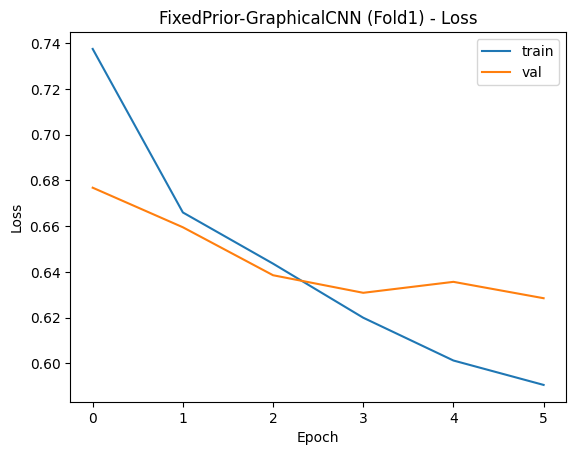

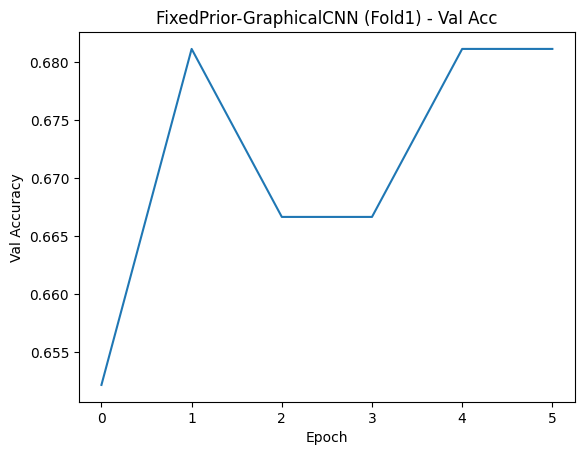

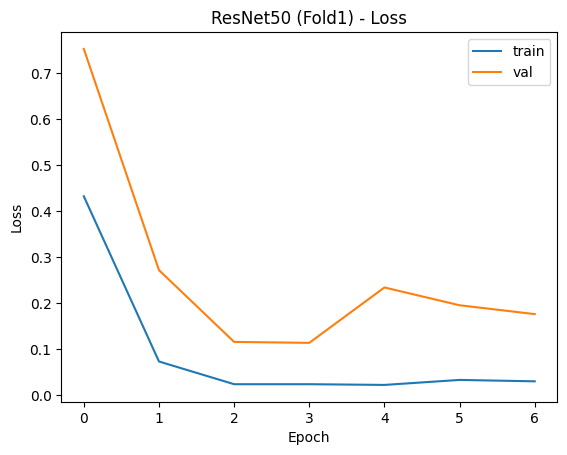

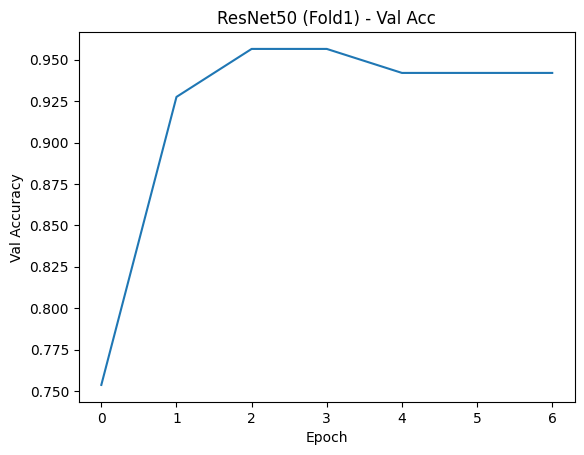

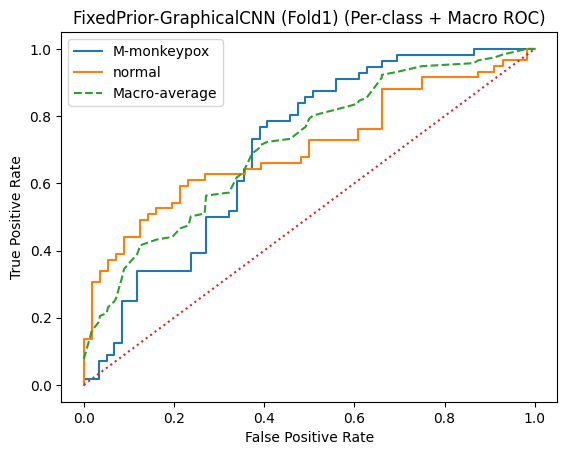

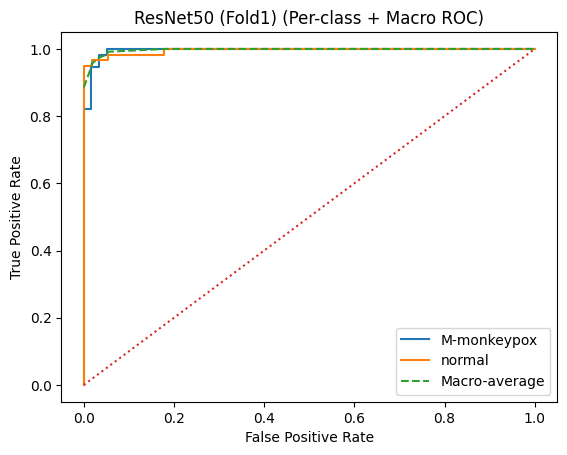

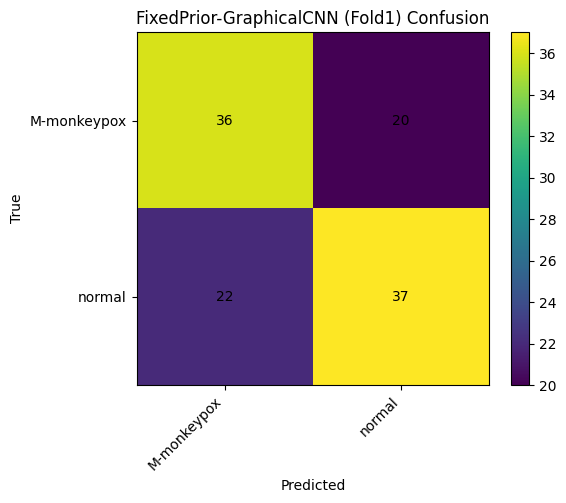

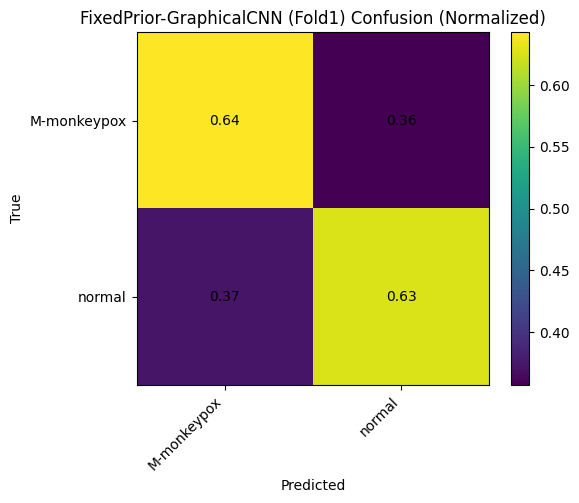

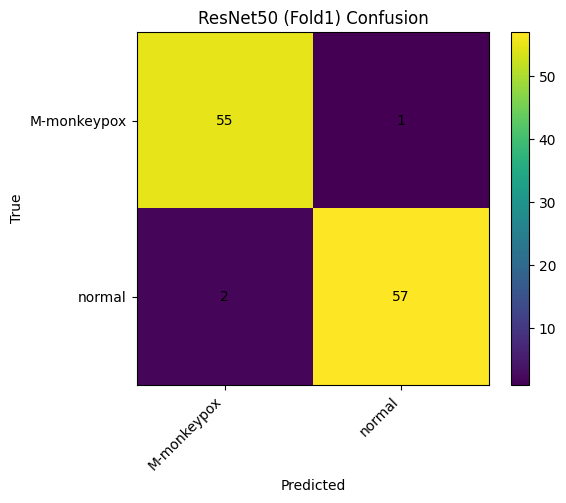

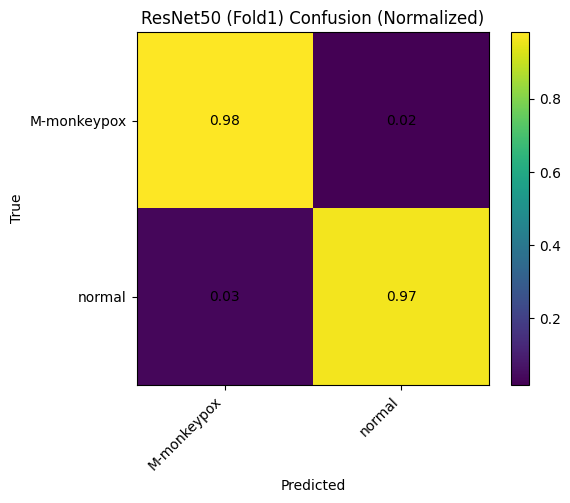

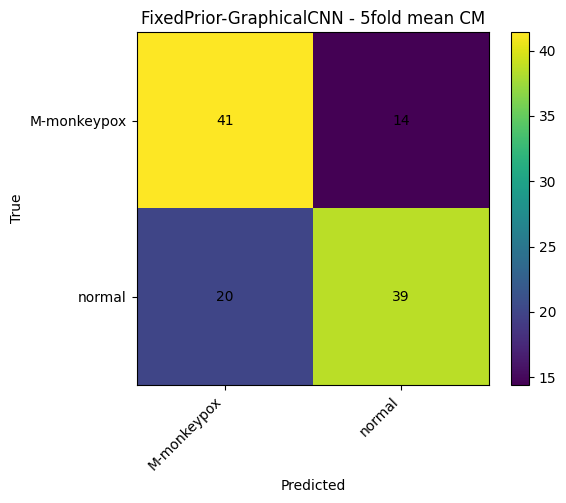

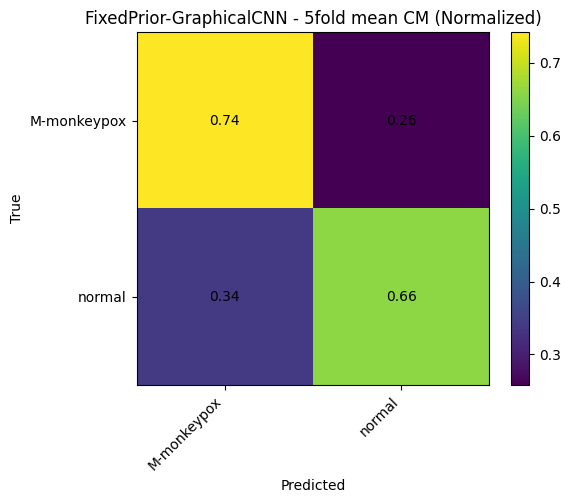


FixedPrior-GraphicalCNN - CM std (raw):


,M-monkeypox,normal
M-monkeypox,3.006659,3.006659
normal,1.264911,1.019804


FixedPrior-GraphicalCNN - CM std (normalized):


,M-monkeypox,normal
M-monkeypox,0.053600,0.053600
normal,0.019793,0.019793


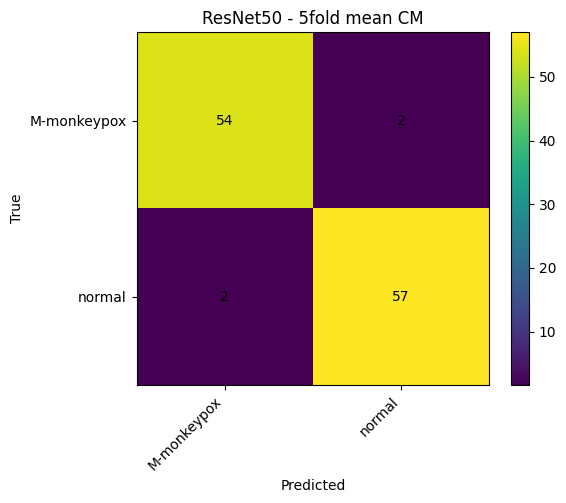

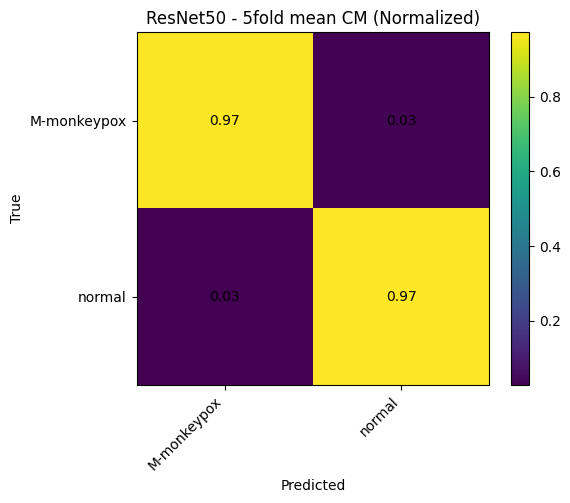


ResNet50 - CM std (raw):


,M-monkeypox,normal
M-monkeypox,1.67332,1.469694
normal,0.80000,1.095445


ResNet50 - CM std (normalized):


,M-monkeypox,normal
M-monkeypox,0.026406,0.026406
normal,0.013824,0.013824


,fold,method,val_best_acc,acc,prec,rec,f1,auc
0,1,FixedPrior-GraphicalCNN,0.681159,0.634783,0.634906,0.634988,0.634755,0.703995
1,1,ResNet50,0.956522,0.973913,0.973835,0.974122,0.973905,0.995763
2,2,FixedPrior-GraphicalCNN,0.811594,0.739130,0.743719,0.740769,0.738636,0.824153
3,2,ResNet50,0.985507,0.991304,0.991228,0.991525,0.991302,1.000000
4,3,FixedPrior-GraphicalCNN,0.724638,0.719298,0.721774,0.720135,0.718952,0.826663
5,3,ResNet50,0.985507,0.956140,0.957779,0.955665,0.956056,0.981527
6,4,FixedPrior-GraphicalCNN,0.695652,0.710526,0.712187,0.711207,0.710326,0.791564
7,4,ResNet50,0.971014,0.964912,0.965209,0.965209,0.964912,0.992919
8,5,FixedPrior-GraphicalCNN,0.811594,0.692982,0.696030,0.694761,0.692770,0.776888
9,5,ResNet50,0.985507,0.964912,0.965976,0.964253,0.964815,0.991371



================= 5-FOLD CV (mean ± std) =================


,model,ACC mean±std,F1 mean±std,AUC mean±std,ValBestAcc mean±std
0,FixedPrior-GraphicalCNN,0.6993 ± 0.0397,0.6991 ± 0.0396,0.7847 ± 0.0498,0.7449 ± 0.0628
1,ResNet50,0.9702 ± 0.0133,0.9702 ± 0.0134,0.9923 ± 0.0069,0.9768 ± 0.0130


Saved: /content/drive/My Drive/1-a-monkeypox/data2//cv5_graphcnn_resnet_results.csv
Saved: /content/drive/My Drive/1-a-monkeypox/data2//cv5_graphcnn_resnet_summary.csv


In [ ]:

!pip -q install opencv-python scikit-image scikit-learn tqdm

import os, glob, random
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score, roc_curve, confusion_matrix
from sklearn.preprocessing import label_binarize

from skimage.feature import local_binary_pattern, graycomatrix, graycoprops

import torchvision
from torchvision import transforms

import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 0) SETTINGS
# =========================
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

assert "DATA_ROOT" in globals(), "DATA_ROOT tanımlı değil. Örn: DATA_ROOT='/content/dataset'"

CLASSES = ["M-monkeypox", "normal"]
NUM_CLASSES = len(CLASSES)

# =========================
# 1) AUTO CLASS FOLDER RESOLVE
# =========================
def _norm_name(s: str) -> str:
    return s.strip().lower().replace("_","").replace("-","").replace(" ","")

def resolve_class_dirs(root, classes):
    assert os.path.isdir(root), f"DATA_ROOT yok: {root}"
    subdirs = [d for d in os.listdir(root) if os.path.isdir(os.path.join(root,d))]
    print("\n[DEBUG] DATA_ROOT alt klasörleri:")
    for d in sorted(subdirs):
        print(" -", repr(d))

    nmap = {_norm_name(d): d for d in subdirs}
    aliases = {
        "M-monkeypox": ["m-monkeypox","monkeypox","mpox","pox","mmonkeypox","monkey_pox","monkeypoxskin","monkeypoximages"],
        "normal": ["normal","healthy","healthyskin","normalskin","clear","nonmpox"]
    }

    class_dirs = {}
    for c in classes:
        found=None
        key=_norm_name(c)
        if key in nmap:
            found=nmap[key]
        else:
            for a in aliases.get(c, []):
                ak=_norm_name(a)
                if ak in nmap:
                    found=nmap[ak]; break
            if found is None:
                for nk, orig in nmap.items():
                    if key in nk or nk in key:
                        found=orig; break
        class_dirs[c]=found

    missing=[c for c,v in class_dirs.items() if v is None]
    if missing:
        raise AssertionError(f"Sınıf klasörü bulunamadı: {missing}. [DEBUG] listesine göre aliases'i genişlet.")
    return class_dirs

class_dirs = resolve_class_dirs(DATA_ROOT, CLASSES)
print("\nResolved class dirs:", class_dirs)

# =========================
# 2) LIST IMAGES
# =========================
class_to_idx = {c:i for i,c in enumerate(CLASSES)}

def list_images(root):
    paths, labels = [], []
    exts = ("*.jpg","*.jpeg","*.png","*.bmp","*.webp")
    for c in CLASSES:
        cdir = os.path.join(root, class_dirs[c])
        files=[]
        for e in exts:
            files += glob.glob(os.path.join(cdir, e))
        files = sorted(files)
        paths += files
        labels += [class_to_idx[c]] * len(files)
    return np.array(paths), np.array(labels)

paths, labels = list_images(DATA_ROOT)
print("\nTotal images:", len(paths))
assert len(paths) > 0, "Görüntü bulunamadı. DATA_ROOT ya da klasör yapısı hatalı."

print("\n[DEBUG] Class counts:")
for c in CLASSES:
    cdir = os.path.join(DATA_ROOT, class_dirs[c])
    n = sum(len(glob.glob(os.path.join(cdir, e))) for e in ("*.jpg","*.jpeg","*.png","*.bmp","*.webp"))
    print(c, "->", n, "| dir:", cdir)

# ============================================================
# 3) Prior smoothness reg (GraphicalCNN)
# ============================================================
def grid_edges(n=3):
    edges=[]
    for r in range(n):
        for c in range(n):
            u=r*n+c
            if r+1<n: edges.append((u,(r+1)*n+c))
            if c+1<n: edges.append((u,r*n+(c+1)))
    return edges

EDGES = grid_edges(3)

def prior_smoothness_loss(feat):  # (B,C,3,3)
    B,C,H,W = feat.shape
    x = feat.view(B,C,H*W)
    loss=0.0
    for u,v in EDGES:
        loss += (x[:,:,u]-x[:,:,v]).pow(2).mean()
    return loss/len(EDGES)

# ============================================================
# 4) Feature extraction (3x3 grid)
# ============================================================
def extract_grid_features(img_rgb, grid=3):
    H,W,_ = img_rgb.shape
    cell = H // grid
    img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

    gx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)
    sob = cv2.magnitude(gx, gy)

    P,R = 8,1
    lbp = local_binary_pattern(gray, P, R, method="uniform")
    lbp_bins = P + 2

    feats=[]
    for i in range(grid):
        row=[]
        for j in range(grid):
            y0,y1 = i*cell, (i+1)*cell if i<grid-1 else H
            x0,x1 = j*cell, (j+1)*cell if j<grid-1 else W
            parts=[]

            p = img_hsv[y0:y1, x0:x1, :].reshape(-1,3).astype(np.float32)
            mean = p.mean(axis=0); std = p.std(axis=0)
            mean[0]/=179.0; std[0]/=179.0
            mean[1:]/=255.0; std[1:]/=255.0
            parts += [mean, std]

            patch_lbp = lbp[y0:y1, x0:x1]
            hist,_ = np.histogram(patch_lbp, bins=np.arange(0, lbp_bins+1), density=False)
            hist = hist.astype(np.float32); hist /= (hist.sum()+1e-6)
            parts += [hist]

            patch_g = gray[y0:y1, x0:x1]
            patch_g = cv2.resize(patch_g, (64,64), interpolation=cv2.INTER_AREA)
            glcm = graycomatrix(patch_g, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)
            props=[]
            for pnm in ["contrast","homogeneity","energy","correlation"]:
                props.append(float(graycoprops(glcm, pnm)[0,0]))
            props = np.array(props, dtype=np.float32)
            props[3] = (props[3]+1.0)/2.0
            parts += [props]

            ps = sob[y0:y1, x0:x1].astype(np.float32)
            e = np.array([ps.mean(), ps.std(), ps.max()], dtype=np.float32)/255.0
            parts += [e]

            row.append(np.concatenate(parts).astype(np.float32))
        feats.append(row)
    return np.array(feats, dtype=np.float32)

Fdim = 6 + 10 + 4 + 3

# ============================================================
# 5) Datasets
# ============================================================
class GraphGridDataset(Dataset):
    def __init__(self, paths, labels, img_size=224, augment=False):
        self.paths=list(paths); self.labels=list(labels)
        self.img_size=img_size; self.augment=augment
    def __len__(self): return len(self.paths)
    def _load_rgb(self, path):
        bgr=cv2.imread(path, cv2.IMREAD_COLOR)
        if bgr is None: raise RuntimeError(f"Cannot read {path}")
        rgb=cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        rgb=cv2.resize(rgb,(self.img_size,self.img_size), interpolation=cv2.INTER_AREA)
        return rgb
    def _augment_rgb(self, rgb):
        if random.random()<0.5: rgb=np.ascontiguousarray(rgb[:, ::-1, :])
        if random.random()<0.15: rgb=np.ascontiguousarray(rgb[::-1, :, :])
        if random.random()<0.25:
            alpha=1.0+random.uniform(-0.12,0.12)
            beta=random.uniform(-10,10)
            rgb=cv2.convertScaleAbs(rgb, alpha=alpha, beta=beta)
        return rgb
    def __getitem__(self, idx):
        rgb=self._load_rgb(self.paths[idx])
        if self.augment: rgb=self._augment_rgb(rgb)
        feats=extract_grid_features(rgb, grid=3)
        x=torch.from_numpy(feats).permute(2,0,1).float()  # (C,3,3)
        y=torch.tensor(int(self.labels[idx]), dtype=torch.long)
        return x,y

class ImageDataset(Dataset):
    def __init__(self, paths, labels, train=False, img_size=224):
        self.paths=list(paths); self.labels=list(labels)
        self.train=train; self.img_size=img_size
        self.tf = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((img_size,img_size)),
            transforms.RandomHorizontalFlip(p=0.5) if train else transforms.Lambda(lambda x:x),
            transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10, hue=0.02) if train else transforms.Lambda(lambda x:x),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
        ])
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        bgr=cv2.imread(self.paths[idx], cv2.IMREAD_COLOR)
        if bgr is None: raise RuntimeError(f"Cannot read {self.paths[idx]}")
        rgb=cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        rgb=cv2.resize(rgb,(self.img_size,self.img_size), interpolation=cv2.INTER_AREA)
        x=self.tf(rgb)
        y=torch.tensor(int(self.labels[idx]), dtype=torch.long)
        return x,y

# ============================================================
# 6) Models
# ============================================================
class GraphicalCNN(nn.Module):
    def __init__(self, in_ch, num_classes, dropout=0.25):
        super().__init__()
        self.conv1=nn.Conv2d(in_ch,64,3,padding=1); self.bn1=nn.BatchNorm2d(64)
        self.conv2=nn.Conv2d(64,128,3,padding=1); self.bn2=nn.BatchNorm2d(128)
        self.pool=nn.AdaptiveAvgPool2d((1,1))
        self.fc1=nn.Linear(128,64); self.drop=nn.Dropout(dropout)
        self.fc2=nn.Linear(64,num_classes)
    def forward(self,x):
        x=F.relu(self.bn1(self.conv1(x)))
        x=F.relu(self.bn2(self.conv2(x)))
        feat=x
        x=self.pool(x).flatten(1)
        x=F.relu(self.fc1(x))
        x=self.drop(x)
        logits=self.fc2(x)
        return logits, feat

def build_resnet50(num_classes):
    m=torchvision.models.resnet50(weights=torchvision.models.ResNet50_Weights.IMAGENET1K_V2)
    m.fc=nn.Linear(m.fc.in_features, num_classes)
    return m

# ============================================================
# 7) Metrics + plots (binary-safe)
# ============================================================
def compute_metrics(y_true, y_pred, y_prob):
    y_true=np.asarray(y_true); y_pred=np.asarray(y_pred); y_prob=np.asarray(y_prob)
    acc=accuracy_score(y_true,y_pred)
    prec,rec,f1,_=precision_recall_fscore_support(y_true,y_pred,average="macro",zero_division=0)

    auc=float("nan")
    try:
        if y_prob.ndim == 1:
            auc = roc_auc_score(y_true, y_prob)
        elif y_prob.shape[1] == 2:
            auc = roc_auc_score(y_true, y_prob[:,1])
        else:
            auc = roc_auc_score(y_true, y_prob, multi_class="ovr")
    except:
        pass
    return {"acc":float(acc),"prec":float(prec),"rec":float(rec),"f1":float(f1),"auc":float(auc)}

def _ensure_prob_2d(y_prob, num_classes):
    y_prob = np.asarray(y_prob)
    if y_prob.ndim == 1:
        y_prob = y_prob.reshape(-1, 1)
    if num_classes == 2 and y_prob.shape[1] == 1:
        p1 = y_prob[:, 0]
        y_prob = np.stack([1 - p1, p1], axis=1)
    return y_prob

def plot_roc_per_class_and_macro_safe(y_true, y_prob, class_names, title):
    y_true = np.asarray(y_true).astype(int)
    K = len(class_names)
    y_prob = _ensure_prob_2d(y_prob, K)

    Y = label_binarize(y_true, classes=list(range(K)))
    if K == 2 and Y.shape[1] == 1:
        Y = np.hstack([1 - Y, Y])

    plt.figure()
    fprs=[]; tprs=[]
    for k in range(K):
        fpr, tpr, _ = roc_curve(Y[:, k], y_prob[:, k])
        plt.plot(fpr, tpr, label=class_names[k])
        fprs.append(fpr); tprs.append(tpr)

    all_fpr = np.unique(np.concatenate(fprs))
    mean_tpr = np.zeros_like(all_fpr)
    for k in range(K):
        mean_tpr += np.interp(all_fpr, fprs[k], tprs[k])
    mean_tpr /= K

    plt.plot(all_fpr, mean_tpr, linestyle="--", label="Macro-average")
    plt.plot([0,1],[0,1], linestyle=":")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title + " (Per-class + Macro ROC)")
    plt.legend()
    plt.show()

def plot_cm_matrix(mat, class_names, title, normalize=False):
    mat = mat.astype(np.float32)
    if normalize:
        mat = mat / (mat.sum(axis=1, keepdims=True) + 1e-9)

    plt.figure(figsize=(6,5))
    plt.imshow(mat, interpolation="nearest")
    plt.title(title + (" (Normalized)" if normalize else ""))
    plt.colorbar()
    ticks = np.arange(len(class_names))
    plt.xticks(ticks, class_names, rotation=45, ha="right")
    plt.yticks(ticks, class_names)
    plt.xlabel("Predicted"); plt.ylabel("True")
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val = mat[i, j]
            txt = f"{val:.2f}" if normalize else f"{int(round(val))}"
            plt.text(j, i, txt, ha="center", va="center")
    plt.tight_layout()
    plt.show()

def plot_history(hist, title):
    plt.figure()
    plt.plot(hist["train_loss"]); plt.plot(hist["val_loss"])
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title(f"{title} - Loss")
    plt.legend(["train","val"]); plt.show()
    plt.figure()
    plt.plot(hist["val_acc"])
    plt.xlabel("Epoch"); plt.ylabel("Val Accuracy"); plt.title(f"{title} - Val Acc")
    plt.show()

# ============================================================
# 8) Train/Eval helpers (early stopping)
# ============================================================
@torch.no_grad()
def predict_probs_graph(model, loader):
    model.eval()
    probs_all=[]; y_all=[]
    for x,y in loader:
        x=x.to(device); y=y.to(device)
        logits,_ = model(x)
        probs_all.append(F.softmax(logits,dim=1).cpu().numpy())
        y_all.append(y.cpu().numpy())
    probs_all=np.concatenate(probs_all,axis=0)
    y_all=np.concatenate(y_all,axis=0)
    pred=probs_all.argmax(axis=1)
    return y_all,pred,probs_all

@torch.no_grad()
def predict_probs_img(model, loader):
    model.eval()
    probs_all=[]; y_all=[]
    for x,y in loader:
        x=x.to(device); y=y.to(device)
        logits = model(x)
        probs_all.append(F.softmax(logits,dim=1).cpu().numpy())
        y_all.append(y.cpu().numpy())
    probs_all=np.concatenate(probs_all,axis=0)
    y_all=np.concatenate(y_all,axis=0)
    pred=probs_all.argmax(axis=1)
    return y_all,pred,probs_all

def run_epoch_train_graph(model, loader, optimizer, lambda_prior=0.0):
    model.train(True)
    crit=nn.CrossEntropyLoss()
    total=0.0
    for x,y in loader:
        x=x.to(device); y=y.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits,feat=model(x)
        ce=crit(logits,y)
        lp=prior_smoothness_loss(feat) if lambda_prior>0 else 0.0
        loss=ce + (lambda_prior*lp if lambda_prior>0 else 0.0)
        loss.backward()
        optimizer.step()
        total += float(loss.item())*x.size(0)
    return total/len(loader.dataset)

def run_epoch_train_img(model, loader, optimizer):
    model.train(True)
    crit=nn.CrossEntropyLoss()
    total=0.0
    for x,y in loader:
        x=x.to(device); y=y.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits=model(x)
        loss=crit(logits,y)
        loss.backward()
        optimizer.step()
        total += float(loss.item())*x.size(0)
    return total/len(loader.dataset)

@torch.no_grad()
def eval_loss_graph(model, loader):
    model.eval()
    crit=nn.CrossEntropyLoss()
    total=0.0
    for x,y in loader:
        x=x.to(device); y=y.to(device)
        logits,_=model(x)
        total += float(crit(logits,y).item())*x.size(0)
    return total/len(loader.dataset)

@torch.no_grad()
def eval_loss_img(model, loader):
    model.eval()
    crit=nn.CrossEntropyLoss()
    total=0.0
    for x,y in loader:
        x=x.to(device); y=y.to(device)
        logits=model(x)
        total += float(crit(logits,y).item())*x.size(0)
    return total/len(loader.dataset)

def train_es_graph(build_fn, dl_tr, dl_va, epochs=15, lr=1e-3, wd=1e-4, patience=4, lambda_prior=0.0):
    model=build_fn().to(device)
    opt=torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    sched=torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="max", factor=0.5, patience=2)

    history={"train_loss":[], "val_loss":[], "val_acc":[], "lr":[]}
    best=-1.0; best_state=None; bad=0

    for _ in range(epochs):
        tr_loss=run_epoch_train_graph(model, dl_tr, opt, lambda_prior=lambda_prior)
        va_loss=eval_loss_graph(model, dl_va)
        yv,pv,probv=predict_probs_graph(model, dl_va)
        mval=compute_metrics(yv,pv,probv)

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(mval["acc"])
        history["lr"].append(opt.param_groups[0]["lr"])
        sched.step(mval["acc"])

        if mval["acc"] > best + 1e-4:
            best=mval["acc"]
            best_state={k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
            bad=0
        else:
            bad += 1
            if bad >= patience:
                break

    model.load_state_dict(best_state)
    return model, best, history

def train_es_img(build_fn, dl_tr, dl_va, epochs=15, lr=3e-4, wd=1e-4, patience=4):
    model=build_fn().to(device)
    opt=torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    sched=torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="max", factor=0.5, patience=2)

    history={"train_loss":[], "val_loss":[], "val_acc":[], "lr":[]}
    best=-1.0; best_state=None; bad=0

    for _ in range(epochs):
        tr_loss=run_epoch_train_img(model, dl_tr, opt)
        va_loss=eval_loss_img(model, dl_va)
        yv,pv,probv=predict_probs_img(model, dl_va)
        mval=compute_metrics(yv,pv,probv)

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(mval["acc"])
        history["lr"].append(opt.param_groups[0]["lr"])
        sched.step(mval["acc"])

        if mval["acc"] > best + 1e-4:
            best=mval["acc"]
            best_state={k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
            bad=0
        else:
            bad += 1
            if bad >= patience:
                break

    model.load_state_dict(best_state)
    return model, best, history

# ============================================================
# 9) 5-Fold CV (ONLY 2 MODELS)
# ============================================================
lambda_prior = 0.15
epochs   = 15
batch_size = 64
val_ratio  = 0.15
lr_graph = 1e-3
lr_rn    = 3e-4

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

rows=[]
fold1_hists={}
fold1_rocs={}
fold_preds = {"FixedPrior-GraphicalCNN": [], "ResNet50": []}

for fold, (trainval_idx, test_idx) in enumerate(skf.split(paths, labels), 1):
    p_trainval, y_trainval = paths[trainval_idx], labels[trainval_idx]
    p_test, y_test         = paths[test_idx], labels[test_idx]

    sss = StratifiedShuffleSplit(n_splits=1, test_size=val_ratio, random_state=SEED+fold)
    tr_idx, va_idx = next(sss.split(p_trainval, y_trainval))
    p_tr, y_tr = p_trainval[tr_idx], y_trainval[tr_idx]
    p_va, y_va = p_trainval[va_idx], y_trainval[va_idx]

    print(f"\n===== Fold {fold}/5 | train {len(p_tr)} | val {len(p_va)} | test {len(p_test)} =====")

    dl_tr_g = DataLoader(GraphGridDataset(p_tr,y_tr,augment=True),  batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
    dl_va_g = DataLoader(GraphGridDataset(p_va,y_va,augment=False), batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    dl_te_g = DataLoader(GraphGridDataset(p_test,y_test,augment=False), batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    dl_tr_i = DataLoader(ImageDataset(p_tr,y_tr,train=True),  batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
    dl_va_i = DataLoader(ImageDataset(p_va,y_va,train=False), batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    dl_te_i = DataLoader(ImageDataset(p_test,y_test,train=False), batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    # ---- A) GraphicalCNN
    def build_graph(): return GraphicalCNN(in_ch=Fdim, num_classes=NUM_CLASSES, dropout=0.25)
    g_model, g_best, g_hist = train_es_graph(
        build_graph, dl_tr_g, dl_va_g, epochs=epochs, lr=lr_graph, wd=1e-4, patience=4, lambda_prior=lambda_prior
    )
    yt, yp, prob = predict_probs_graph(g_model, dl_te_g)
    m = compute_metrics(yt, yp, prob)
    rows.append({"fold":fold, "method":"FixedPrior-GraphicalCNN", "val_best_acc":g_best, **m})
    fold_preds["FixedPrior-GraphicalCNN"].append((yt.copy(), yp.copy()))
    if fold == 1:
        fold1_hists["FixedPrior-GraphicalCNN"] = g_hist
        fold1_rocs["FixedPrior-GraphicalCNN"]  = (yt.copy(), prob.copy())

    # ---- B) ResNet50
    def build_rn(): return build_resnet50(num_classes=NUM_CLASSES)
    rn_model, rn_best, rn_hist = train_es_img(
        build_rn, dl_tr_i, dl_va_i, epochs=epochs, lr=lr_rn, wd=1e-4, patience=4
    )
    yt, yp, prob = predict_probs_img(rn_model, dl_te_i)
    m = compute_metrics(yt, yp, prob)
    rows.append({"fold":fold, "method":"ResNet50", "val_best_acc":rn_best, **m})
    fold_preds["ResNet50"].append((yt.copy(), yp.copy()))
    if fold == 1:
        fold1_hists["ResNet50"] = rn_hist
        fold1_rocs["ResNet50"]  = (yt.copy(), prob.copy())

# ============================================================
# 10) Fold-1 plots: Loss/Acc + ROC + CM
# ============================================================
for name, hist in fold1_hists.items():
    plot_history(hist, f"{name} (Fold1)")

for name, (yt, prob) in fold1_rocs.items():
    plot_roc_per_class_and_macro_safe(yt, prob, CLASSES, f"{name} (Fold1)")

for name, (yt, prob) in fold1_rocs.items():
    prob2 = _ensure_prob_2d(prob, NUM_CLASSES)
    y_pred = prob2.argmax(axis=1)
    cmx = confusion_matrix(yt, y_pred, labels=list(range(NUM_CLASSES))).astype(np.float32)
    plot_cm_matrix(cmx, CLASSES, f"{name} (Fold1) Confusion", normalize=False)
    plot_cm_matrix(cmx, CLASSES, f"{name} (Fold1) Confusion", normalize=True)

# ============================================================
# 11) 5-Fold mean±std CM (per method)
# ============================================================
for method in fold_preds.keys():
    cms=[]; cms_n=[]
    for (yt, ypred) in fold_preds[method]:
        cmx = confusion_matrix(yt, ypred, labels=list(range(NUM_CLASSES))).astype(np.float32)
        cms.append(cmx)
        cmn = cmx / (cmx.sum(axis=1, keepdims=True) + 1e-9)
        cms_n.append(cmn)

    cms = np.stack(cms, axis=0)
    cms_n = np.stack(cms_n, axis=0)
    cm_mean, cm_std   = cms.mean(axis=0),   cms.std(axis=0)
    cmn_mean, cmn_std = cms_n.mean(axis=0), cms_n.std(axis=0)

    plot_cm_matrix(cm_mean,  CLASSES, f"{method} - 5fold mean CM", normalize=False)
    plot_cm_matrix(cmn_mean, CLASSES, f"{method} - 5fold mean CM", normalize=True)

    print(f"\n{method} - CM std (raw):")
    display(pd.DataFrame(cm_std, index=CLASSES, columns=CLASSES))
    print(f"{method} - CM std (normalized):")
    display(pd.DataFrame(cmn_std, index=CLASSES, columns=CLASSES))

# ============================================================
# 12) Tables + Save
# ============================================================
df = pd.DataFrame(rows)
display(df)

def mean_std_table(df):
    out=[]
    for m in df["method"].unique():
        d=df[df["method"]==m]
        out.append({
            "model": m,
            "ACC mean±std": f"{d['acc'].mean():.4f} ± {d['acc'].std():.4f}",
            "F1  mean±std": f"{d['f1'].mean():.4f} ± {d['f1'].std():.4f}",
            "AUC mean±std": f"{d['auc'].mean():.4f} ± {d['auc'].std():.4f}",
            "ValBestAcc mean±std": f"{d['val_best_acc'].mean():.4f} ± {d['val_best_acc'].std():.4f}",
        })
    return pd.DataFrame(out)

summary = mean_std_table(df)
print("\n================= 5-FOLD CV (mean ± std) =================")
display(summary)

OUT_CSV = f"{DATA_ROOT}/cv5_graphcnn_resnet_results.csv"
OUT_SUM = f"{DATA_ROOT}/cv5_graphcnn_resnet_summary.csv"
df.to_csv(OUT_CSV, index=False)
summary.to_csv(OUT_SUM, index=False)
print("Saved:", OUT_CSV)
print("Saved:", OUT_SUM)


Device: cuda

[DEBUG] DATA_ROOT alt klasörleri:
 - 'monkeypox'
 - 'normal'

Resolved class dirs: {'M-monkeypox': 'monkeypox', 'normal': 'normal'}

Total images: 572

[DEBUG] Class counts:
M-monkeypox -> 279 | dir: /content/drive/My Drive/1-a-monkeypox/data2/monkeypox
normal -> 293 | dir: /content/drive/My Drive/1-a-monkeypox/data2/normal

===== Fold 1/5 | train 388 | val 69 | test 115 =====
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 236MB/s]


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 197MB/s]



===== Fold 2/5 | train 388 | val 69 | test 115 =====

===== Fold 3/5 | train 389 | val 69 | test 114 =====

===== Fold 4/5 | train 389 | val 69 | test 114 =====

===== Fold 5/5 | train 389 | val 69 | test 114 =====


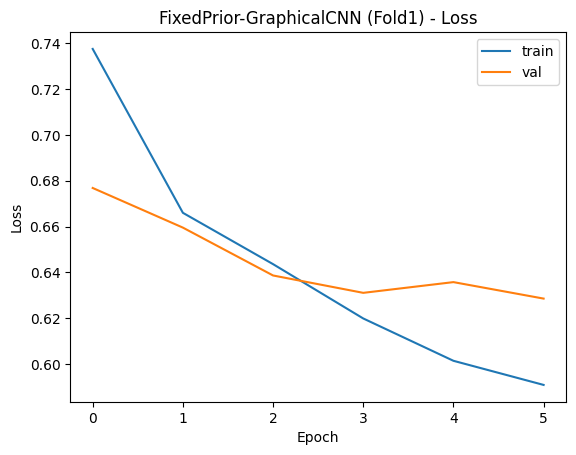

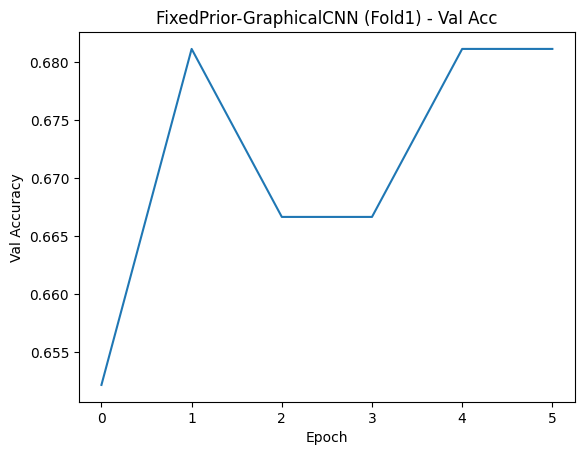

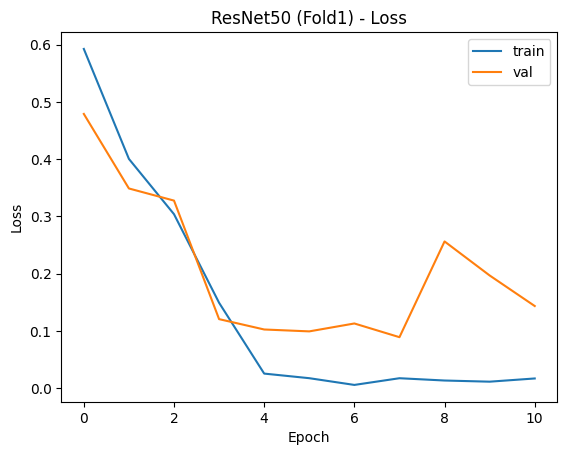

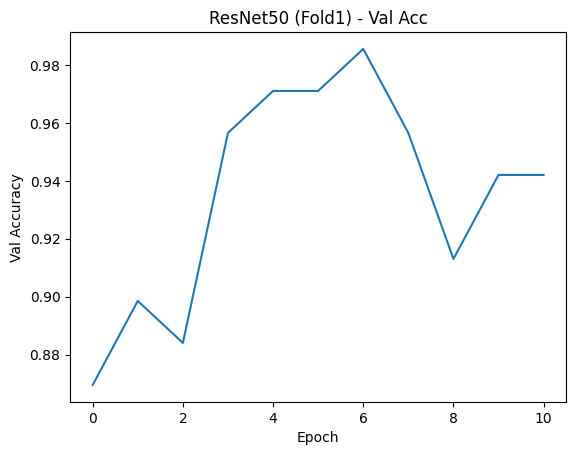

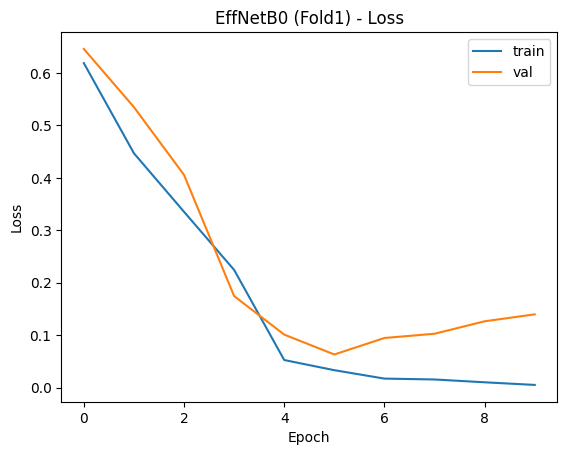

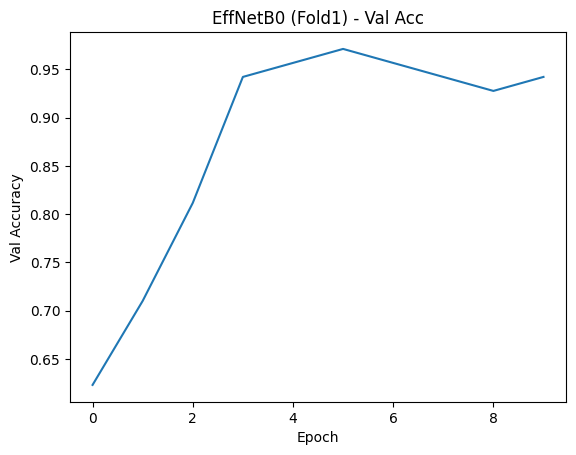

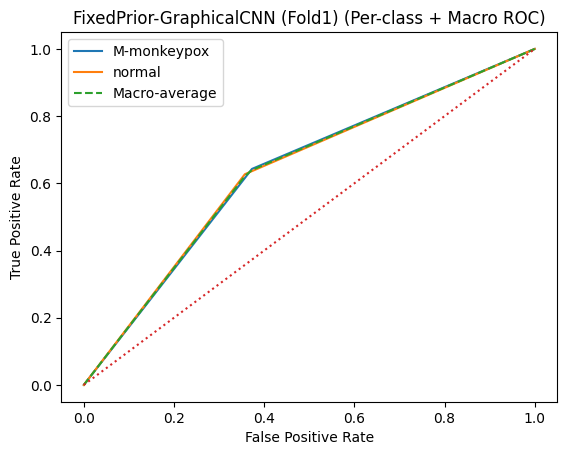

FixedPrior-GraphicalCNN (Fold1) | AUC(pos=normal): 0.6350


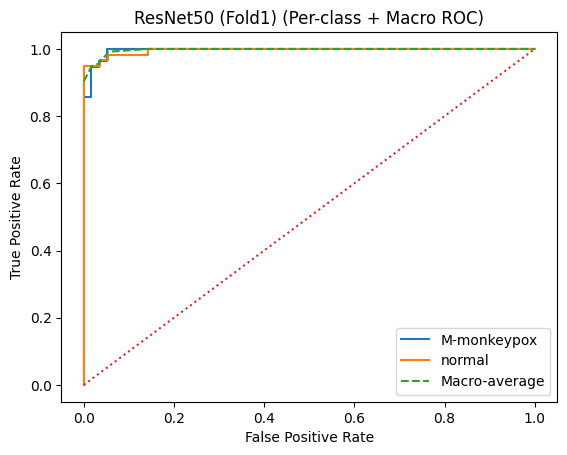

ResNet50 (Fold1) | AUC(pos=normal): 0.9961


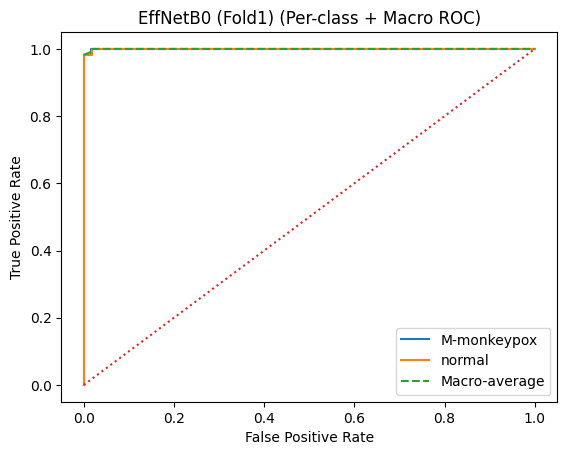

EffNetB0 (Fold1) | AUC(pos=normal): 0.9997


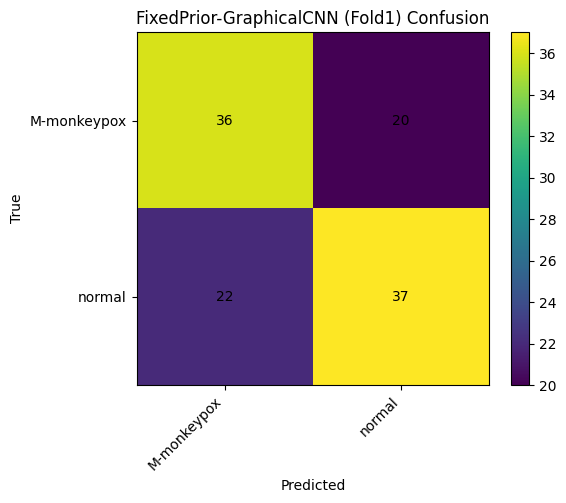

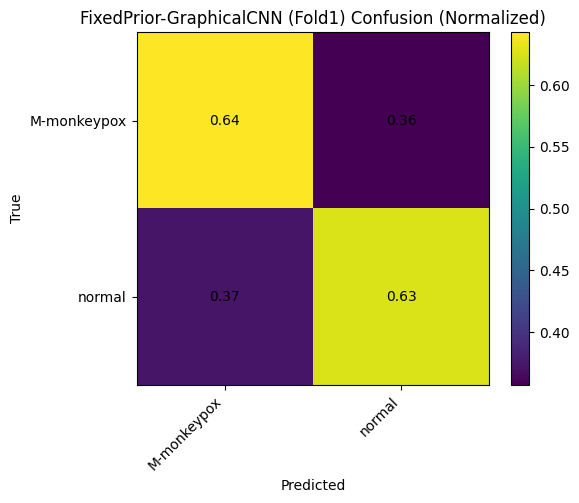

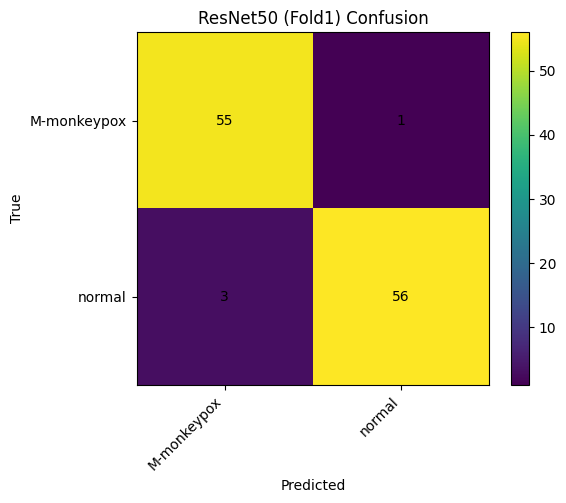

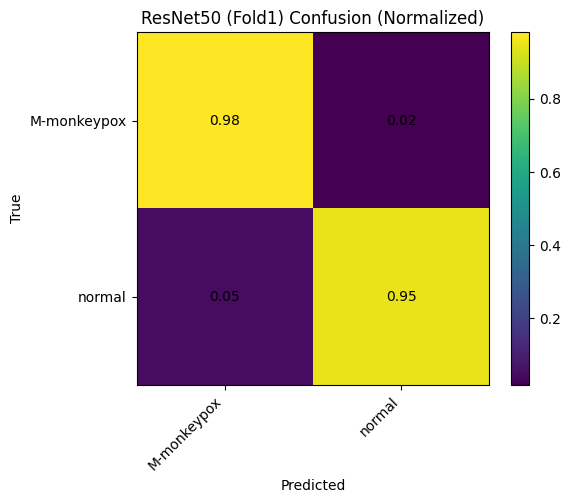

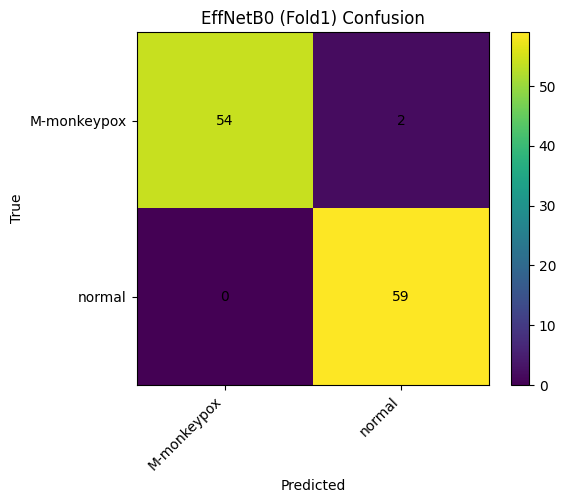

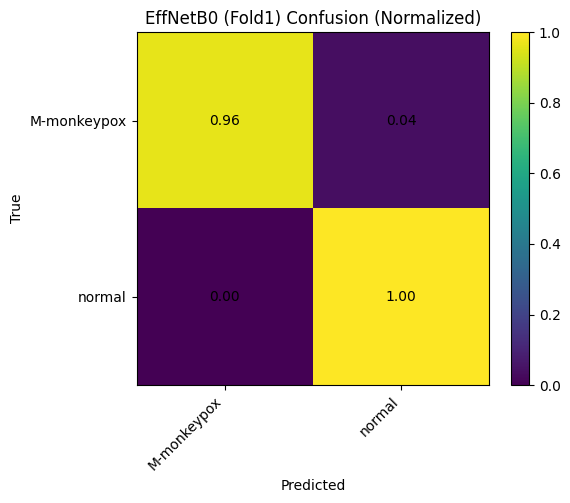

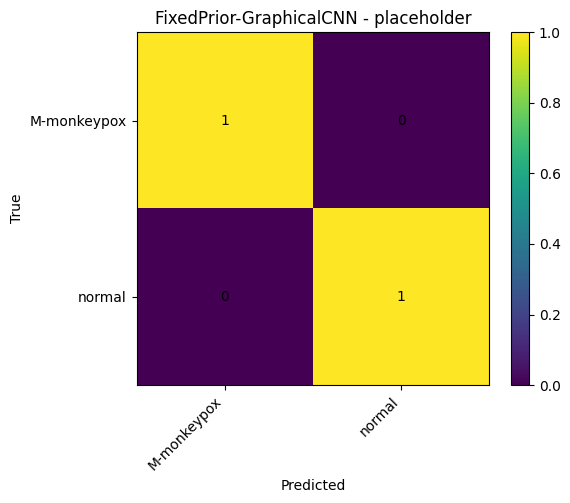

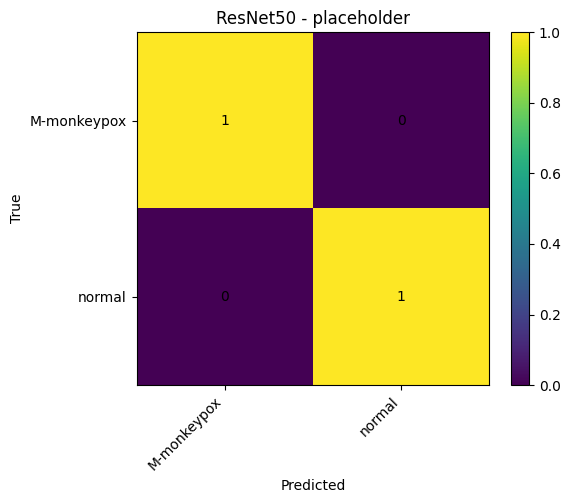

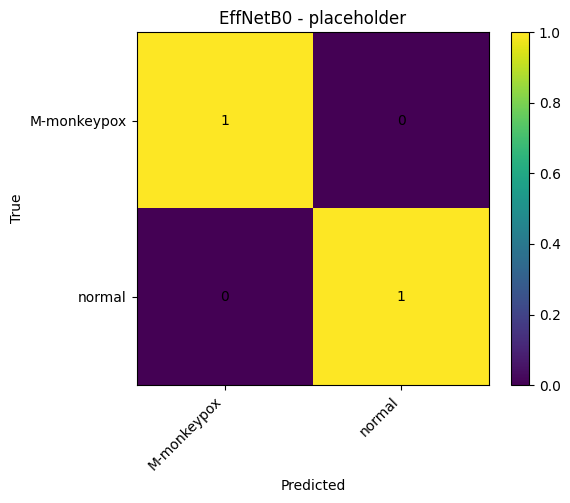

,fold,method,val_best_acc,T,epochs_head,epochs_all,acc,prec,rec,f1,auc
0,1,FixedPrior-GraphicalCNN,0.681159,9.454158e-33,0,12,0.634783,0.634906,0.634988,0.634755,0.634988
1,1,ResNet50,0.985507,1.316566e+00,3,12,0.965217,0.965366,0.965648,0.965215,0.996065
2,1,EffNetB0,0.971014,5.971103e-01,3,12,0.982609,0.983607,0.982143,0.982576,0.999697
3,2,FixedPrior-GraphicalCNN,0.811594,7.002466e-01,0,12,0.773913,0.776923,0.772397,0.772520,0.874697
4,2,ResNet50,0.971014,1.781825e+00,3,12,0.991304,0.991228,0.991525,0.991302,1.000000
5,2,EffNetB0,1.000000,1.875716e-03,3,12,1.000000,1.000000,1.000000,1.000000,1.000000
6,3,FixedPrior-GraphicalCNN,0.768116,1.209272e+00,0,12,0.807018,0.807266,0.807266,0.807018,0.858067
7,3,ResNet50,1.000000,8.036111e-03,3,12,0.947368,0.950062,0.946736,0.947222,0.946736
8,3,EffNetB0,0.971014,8.677946e-01,3,12,0.956140,0.960317,0.955357,0.955974,0.992919
9,4,FixedPrior-GraphicalCNN,0.724638,1.524332e+00,0,12,0.710526,0.711094,0.710899,0.710504,0.797414


In [ ]:


# ============================================================
# ONE-CELL FINAL (2-class: M-monkeypox vs normal)
# - AUTO CLASS FOLDER MATCH
# - 5-FOLD CV: GraphicalCNN + ResNet50 + EfficientNetB0
# - Fine-tune (epochs_head + epochs_all)
# - ROC (BINARY SAFE: per-class + macro) + Confusion (Fold1 + mean±std)
# - Representative Explainability: Grad-CAM (ResNet/EffNet) + 3×3 importance (GraphicalCNN)
# ============================================================
!pip -q install opencv-python scikit-image scikit-learn tqdm

import os, glob, random
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score, roc_curve, confusion_matrix
from sklearn.preprocessing import label_binarize
from skimage.feature import local_binary_pattern, graycomatrix, graycoprops
import torchvision
from torchvision import transforms
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# =========================
# 0) SETTINGS
# =========================
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# !!! DATA_ROOT'u SEN belirle (örnek):
# DATA_ROOT = "/content/dataset"
# DATA_ROOT = r"C:\...\dataset"
assert "DATA_ROOT" in globals(), "DATA_ROOT tanımlı değil. Örn: DATA_ROOT='/content/dataset'"

CLASSES = ["M-monkeypox", "normal"]
NUM_CLASSES = len(CLASSES)

# =========================
# 1) AUTO CLASS FOLDER RESOLVE
# =========================
def _norm_name(s: str) -> str:
    return s.strip().lower().replace("_","").replace("-","").replace(" ","")

def resolve_class_dirs(root, classes):
    assert os.path.isdir(root), f"DATA_ROOT yok: {root}"
    subdirs = [d for d in os.listdir(root) if os.path.isdir(os.path.join(root,d))]
    print("\n[DEBUG] DATA_ROOT alt klasörleri:")
    for d in sorted(subdirs):
        print(" -", repr(d))

    nmap = {_norm_name(d): d for d in subdirs}
    aliases = {
        "M-monkeypox": ["m-monkeypox","monkeypox","mpox","pox","mmonkeypox","monkey_pox","monkeypoxskin","monkeypoximages"],
        "normal": ["normal","healthy","healthyskin","normalskin","clear","nonmpox"]
    }

    class_dirs = {}
    for c in classes:
        found=None
        key=_norm_name(c)
        if key in nmap:
            found=nmap[key]
        else:
            for a in aliases.get(c, []):
                ak=_norm_name(a)
                if ak in nmap:
                    found=nmap[ak]; break
            if found is None:
                for nk, orig in nmap.items():
                    if key in nk or nk in key:
                        found=orig; break
        class_dirs[c]=found

    missing=[c for c,v in class_dirs.items() if v is None]
    if missing:
        raise AssertionError(f"Sınıf klasörü bulunamadı: {missing}. [DEBUG] listesine göre aliases'i genişlet.")
    return class_dirs

class_dirs = resolve_class_dirs(DATA_ROOT, CLASSES)
print("\nResolved class dirs:", class_dirs)

# =========================
# 2) LIST IMAGES
# =========================
class_to_idx = {c:i for i,c in enumerate(CLASSES)}

def list_images(root):
    paths, labels = [], []
    exts = ("*.jpg","*.jpeg","*.png","*.bmp","*.webp")
    for c in CLASSES:
        cdir = os.path.join(root, class_dirs[c])
        files=[]
        for e in exts:
            files += glob.glob(os.path.join(cdir, e))
        files = sorted(files)
        paths += files
        labels += [class_to_idx[c]] * len(files)
    return np.array(paths), np.array(labels)

paths, labels = list_images(DATA_ROOT)
print("\nTotal images:", len(paths))
assert len(paths) > 0, "Görüntü bulunamadı. DATA_ROOT ya da klasör yapısı hatalı."

print("\n[DEBUG] Class counts:")
for c in CLASSES:
    cdir = os.path.join(DATA_ROOT, class_dirs[c])
    n = sum(len(glob.glob(os.path.join(cdir, e))) for e in ("*.jpg","*.jpeg","*.png","*.bmp","*.webp"))
    print(c, "->", n, "| dir:", cdir)

# ============================================================
# 3) Fixed priors + prior smoothness reg
# ============================================================
def grid_edges(n=3):
    edges=[]
    for r in range(n):
        for c in range(n):
            u=r*n+c
            if r+1<n: edges.append((u,(r+1)*n+c))
            if c+1<n: edges.append((u,r*n+(c+1)))
    return edges

EDGES = grid_edges(3)

def prior_smoothness_loss(feat):  # (B,C,3,3)
    B,C,H,W = feat.shape
    x = feat.view(B,C,H*W)
    loss=0.0
    for u,v in EDGES:
        loss += (x[:,:,u]-x[:,:,v]).pow(2).mean()
    return loss/len(EDGES)

# ============================================================
# 4) Feature extraction (3x3 grid)
# ============================================================
def extract_grid_features(img_rgb, grid=3):
    H,W,_ = img_rgb.shape
    cell = H // grid
    img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

    gx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)
    sob = cv2.magnitude(gx, gy)

    P,R = 8,1
    lbp = local_binary_pattern(gray, P, R, method="uniform")
    lbp_bins = P + 2

    feats=[]
    for i in range(grid):
        row=[]
        for j in range(grid):
            y0,y1 = i*cell, (i+1)*cell if i<grid-1 else H
            x0,x1 = j*cell, (j+1)*cell if j<grid-1 else W
            parts=[]

            p = img_hsv[y0:y1, x0:x1, :].reshape(-1,3).astype(np.float32)
            mean = p.mean(axis=0); std = p.std(axis=0)
            mean[0]/=179.0; std[0]/=179.0
            mean[1:]/=255.0; std[1:]/=255.0
            parts += [mean, std]

            patch_lbp = lbp[y0:y1, x0:x1]
            hist,_ = np.histogram(patch_lbp, bins=np.arange(0, lbp_bins+1), density=False)
            hist = hist.astype(np.float32); hist /= (hist.sum()+1e-6)
            parts += [hist]

            patch_g = gray[y0:y1, x0:x1]
            patch_g = cv2.resize(patch_g, (64,64), interpolation=cv2.INTER_AREA)
            glcm = graycomatrix(patch_g, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)
            props=[]
            for pnm in ["contrast","homogeneity","energy","correlation"]:
                props.append(float(graycoprops(glcm, pnm)[0,0]))
            props = np.array(props, dtype=np.float32)
            props[3] = (props[3]+1.0)/2.0
            parts += [props]

            ps = sob[y0:y1, x0:x1].astype(np.float32)
            e = np.array([ps.mean(), ps.std(), ps.max()], dtype=np.float32)/255.0
            parts += [e]

            row.append(np.concatenate(parts).astype(np.float32))
        feats.append(row)
    return np.array(feats, dtype=np.float32)

Fdim = 6 + 10 + 4 + 3

# ============================================================
# 5) Datasets
# ============================================================
class GraphGridDataset(Dataset):
    def __init__(self, paths, labels, img_size=224, augment=False):
        self.paths=list(paths); self.labels=list(labels)
        self.img_size=img_size; self.augment=augment
    def __len__(self): return len(self.paths)
    def _load_rgb(self, path):
        bgr=cv2.imread(path, cv2.IMREAD_COLOR)
        if bgr is None: raise RuntimeError(f"Cannot read {path}")
        rgb=cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        rgb=cv2.resize(rgb,(self.img_size,self.img_size), interpolation=cv2.INTER_AREA)
        return rgb
    def _augment_rgb(self, rgb):
        if random.random()<0.5: rgb=np.ascontiguousarray(rgb[:, ::-1, :])
        if random.random()<0.15: rgb=np.ascontiguousarray(rgb[::-1, :, :])
        if random.random()<0.25:
            alpha=1.0+random.uniform(-0.12,0.12)
            beta=random.uniform(-10,10)
            rgb=cv2.convertScaleAbs(rgb, alpha=alpha, beta=beta)
        return rgb
    def __getitem__(self, idx):
        rgb=self._load_rgb(self.paths[idx])
        if self.augment: rgb=self._augment_rgb(rgb)
        feats=extract_grid_features(rgb, grid=3)
        x=torch.from_numpy(feats).permute(2,0,1).float()  # (C,3,3)
        y=torch.tensor(int(self.labels[idx]), dtype=torch.long)
        return x,y

class ImageDataset(Dataset):
    def __init__(self, paths, labels, train=False, img_size=224):
        self.paths=list(paths); self.labels=list(labels)
        self.train=train; self.img_size=img_size
        self.tf = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((img_size,img_size)),
            transforms.RandomHorizontalFlip(p=0.5) if train else transforms.Lambda(lambda x:x),
            transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10, hue=0.02) if train else transforms.Lambda(lambda x:x),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
        ])
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        bgr=cv2.imread(self.paths[idx], cv2.IMREAD_COLOR)
        if bgr is None: raise RuntimeError(f"Cannot read {self.paths[idx]}")
        rgb=cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        rgb=cv2.resize(rgb,(self.img_size,self.img_size), interpolation=cv2.INTER_AREA)
        x=self.tf(rgb)
        y=torch.tensor(int(self.labels[idx]), dtype=torch.long)
        return x,y

# ============================================================
# 6) Models
# ============================================================
class GraphicalCNN(nn.Module):
    def __init__(self, in_ch, num_classes, dropout=0.25):
        super().__init__()
        self.conv1=nn.Conv2d(in_ch,64,3,padding=1); self.bn1=nn.BatchNorm2d(64)
        self.conv2=nn.Conv2d(64,128,3,padding=1); self.bn2=nn.BatchNorm2d(128)
        self.pool=nn.AdaptiveAvgPool2d((1,1))
        self.fc1=nn.Linear(128,64); self.drop=nn.Dropout(dropout)
        self.fc2=nn.Linear(64,num_classes)
    def forward(self,x):
        x=F.relu(self.bn1(self.conv1(x)))
        x=F.relu(self.bn2(self.conv2(x)))
        feat=x
        x=self.pool(x).flatten(1)
        x=F.relu(self.fc1(x))
        x=self.drop(x)
        logits=self.fc2(x)
        return logits, feat

def build_resnet50(num_classes):
    m=torchvision.models.resnet50(weights=torchvision.models.ResNet50_Weights.IMAGENET1K_V2)
    m.fc=nn.Linear(m.fc.in_features, num_classes)
    return m

def build_efficientnet_b0(num_classes):
    m=torchvision.models.efficientnet_b0(weights=torchvision.models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    m.classifier[1]=nn.Linear(m.classifier[1].in_features, num_classes)
    return m

# ============================================================
# 7) Metrics + utilities
# ============================================================
def compute_metrics(y_true, y_pred, y_prob):
    y_true=np.asarray(y_true); y_pred=np.asarray(y_pred); y_prob=np.asarray(y_prob)
    acc=accuracy_score(y_true,y_pred)
    prec,rec,f1,_=precision_recall_fscore_support(y_true,y_pred,average="macro",zero_division=0)

    auc=float("nan")
    try:
        if y_prob.ndim == 1:
            auc = roc_auc_score(y_true, y_prob)
        elif y_prob.shape[1] == 2:
            auc = roc_auc_score(y_true, y_prob[:,1])
        else:
            auc = roc_auc_score(y_true, y_prob, multi_class="ovr")
    except:
        pass

    return {"acc":float(acc),"prec":float(prec),"rec":float(rec),"f1":float(f1),"auc":float(auc)}

@torch.no_grad()
def predict_probs(model, loader, is_graphical):
    model.eval()
    probs_all=[]; y_all=[]
    for x,y in loader:
        x=x.to(device); y=y.to(device)
        if is_graphical: logits,_=model(x)
        else: logits=model(x)
        probs_all.append(F.softmax(logits,dim=1).cpu().numpy())
        y_all.append(y.cpu().numpy())
    probs_all=np.concatenate(probs_all,axis=0)
    y_all=np.concatenate(y_all,axis=0)
    pred=probs_all.argmax(axis=1)
    return y_all,pred,probs_all

def run_epoch_train(model, loader, optimizer, is_graphical, lambda_prior=0.0):
    model.train(True)
    crit=nn.CrossEntropyLoss()
    total=0.0
    for x,y in loader:
        x=x.to(device); y=y.to(device)
        optimizer.zero_grad(set_to_none=True)
        if is_graphical:
            logits,feat=model(x)
            ce=crit(logits,y)
            lp=prior_smoothness_loss(feat) if lambda_prior>0 else 0.0
            loss=ce + (lambda_prior*lp if lambda_prior>0 else 0.0)
        else:
            logits=model(x)
            loss=crit(logits,y)
        loss.backward()
        optimizer.step()
        total += float(loss.item())*x.size(0)
    return total/len(loader.dataset)

@torch.no_grad()
def eval_loss(model, loader, is_graphical):
    model.eval()
    crit=nn.CrossEntropyLoss()
    total=0.0
    for x,y in loader:
        x=x.to(device); y=y.to(device)
        if is_graphical: logits,_=model(x)
        else: logits=model(x)
        total += float(crit(logits,y).item())*x.size(0)
    return total/len(loader.dataset)

class TemperatureScaler(nn.Module):
    def __init__(self):
        super().__init__()
        self.log_t=nn.Parameter(torch.zeros(1))
    def forward(self, logits):
        T=torch.exp(self.log_t)+1e-6
        return logits/T

def fit_temperature_on_val(model, val_loader, is_graphical, max_iter=200):
    model.eval()
    ts=TemperatureScaler().to(device)
    logits_list=[]; y_list=[]
    with torch.no_grad():
        for x,y in val_loader:
            x=x.to(device); y=y.to(device)
            if is_graphical: logits,_=model(x)
            else: logits=model(x)
            logits_list.append(logits); y_list.append(y)
    logits_all=torch.cat(logits_list,dim=0)
    y_all=torch.cat(y_list,dim=0)

    opt=torch.optim.LBFGS(ts.parameters(), lr=0.1, max_iter=max_iter)
    def closure():
        opt.zero_grad(set_to_none=True)
        loss=F.cross_entropy(ts(logits_all), y_all)
        loss.backward()
        return loss
    opt.step(closure)
    T=float(torch.exp(ts.log_t).detach().cpu().item())
    return ts, T

@torch.no_grad()
def calibrated_test_probs(model, ts, test_loader, is_graphical):
    model.eval()
    probs=[]
    for x,y in test_loader:
        x=x.to(device)
        if is_graphical: logits,_=model(x)
        else: logits=model(x)
        logits=ts(logits)
        probs.append(F.softmax(logits,dim=1).cpu().numpy())
    return np.concatenate(probs,axis=0)

# -------------------------
# ROC + CM (BINARY SAFE)
# -------------------------
def _ensure_prob_2d(y_prob, num_classes):
    y_prob = np.asarray(y_prob)
    if y_prob.ndim == 1:
        y_prob = y_prob.reshape(-1, 1)
    if num_classes == 2 and y_prob.shape[1] == 1:
        p1 = y_prob[:, 0]
        y_prob = np.stack([1 - p1, p1], axis=1)
    return y_prob

def plot_roc_per_class_and_macro_safe(y_true, y_prob, class_names, title):
    y_true = np.asarray(y_true).astype(int)
    K = len(class_names)
    y_prob = _ensure_prob_2d(y_prob, K)

    Y = label_binarize(y_true, classes=list(range(K)))
    if K == 2 and Y.shape[1] == 1:
        Y = np.hstack([1 - Y, Y])

    plt.figure()
    fprs=[]; tprs=[]
    for k in range(K):
        fpr, tpr, _ = roc_curve(Y[:, k], y_prob[:, k])
        plt.plot(fpr, tpr, label=class_names[k])
        fprs.append(fpr); tprs.append(tpr)

    all_fpr = np.unique(np.concatenate(fprs))
    mean_tpr = np.zeros_like(all_fpr)
    for k in range(K):
        mean_tpr += np.interp(all_fpr, fprs[k], tprs[k])
    mean_tpr /= K

    plt.plot(all_fpr, mean_tpr, linestyle="--", label="Macro-average")
    plt.plot([0,1],[0,1], linestyle=":")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title + " (Per-class + Macro ROC)")
    plt.legend()
    plt.show()

    try:
        auc_pos = roc_auc_score(y_true, y_prob[:,1])
        print(f"{title} | AUC(pos={class_names[1]}): {auc_pos:.4f}")
    except:
        pass

def plot_confusion_from_preds(y_true, y_pred, class_names, title, normalize=False):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    K = len(class_names)
    cmx = confusion_matrix(y_true, y_pred, labels=list(range(K))).astype(np.float32)
    if normalize:
        cmx = cmx / (cmx.sum(axis=1, keepdims=True) + 1e-9)

    plt.figure(figsize=(6,5))
    plt.imshow(cmx, interpolation="nearest")
    plt.title(title + (" (Normalized)" if normalize else ""))
    plt.colorbar()
    ticks = np.arange(K)
    plt.xticks(ticks, class_names, rotation=45, ha="right")
    plt.yticks(ticks, class_names)
    plt.xlabel("Predicted"); plt.ylabel("True")

    for i in range(K):
        for j in range(K):
            val = cmx[i, j]
            txt = f"{val:.2f}" if normalize else f"{int(val)}"
            plt.text(j, i, txt, ha="center", va="center")
    plt.tight_layout()
    plt.show()
    return cmx

def plot_history(hist, title):
    plt.figure()
    plt.plot(hist["train_loss"]); plt.plot(hist["val_loss"])
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title(f"{title} - Loss")
    plt.legend(["train","val"]); plt.show()
    plt.figure()
    plt.plot(hist["val_acc"])
    plt.xlabel("Epoch"); plt.ylabel("Val Accuracy"); plt.title(f"{title} - Val Acc")
    plt.show()

# ============================================================
# 8) Fine-tuning (epoch sayısı dahil)
# ============================================================
def set_requires_grad(module, flag: bool):
    for p in module.parameters():
        p.requires_grad = flag

def freeze_backbone_resnet(m):
    set_requires_grad(m, False)
    set_requires_grad(m.fc, True)

def freeze_backbone_effnet(m):
    set_requires_grad(m, False)
    set_requires_grad(m.classifier, True)

def make_optimizer(model, lr, wd):
    params = [p for p in model.parameters() if p.requires_grad]
    return torch.optim.AdamW(params, lr=lr, weight_decay=wd)

def train_with_early_stopping_finetune(
    build_fn,
    train_loader, val_loader,
    is_graphical,
    epochs_head=3,          # head fine-tune epoch
    epochs_all=12,          # full fine-tune epoch
    lr_head=1e-3,
    lr_all=3e-4,
    wd=1e-4,
    patience=4,
    lambda_prior=0.0,
    freeze_backbone_fn=None
):
    model = build_fn().to(device)

    history = {"train_loss":[], "val_loss":[], "val_acc":[], "lr":[]}
    best=-1.0; best_state=None; bad=0

    def run_train_val(opt, sched, n_epochs):
        nonlocal best, best_state, bad
        for ep in range(1, n_epochs+1):
            tr_loss = run_epoch_train(model, train_loader, opt, is_graphical, lambda_prior=lambda_prior)
            va_loss = eval_loss(model, val_loader, is_graphical)
            yv,pv,probv = predict_probs(model, val_loader, is_graphical)
            mval = compute_metrics(yv,pv,probv)

            history["train_loss"].append(tr_loss)
            history["val_loss"].append(va_loss)
            history["val_acc"].append(mval["acc"])
            history["lr"].append(opt.param_groups[0]["lr"])
            sched.step(mval["acc"])

            if mval["acc"] > best + 1e-4:
                best = mval["acc"]
                best_state = {k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
                bad = 0
            else:
                bad += 1
                if bad >= patience:
                    return

    # GraphicalCNN: direkt full train
    if is_graphical or freeze_backbone_fn is None:
        opt = torch.optim.AdamW(model.parameters(), lr=lr_all, weight_decay=wd)
        sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="max", factor=0.5, patience=2)
        run_train_val(opt, sched, epochs_all)
        model.load_state_dict(best_state); model.to(device)
        return model, best, history

    # Phase-1: head train (backbone frozen)
    freeze_backbone_fn(model)
    opt = make_optimizer(model, lr_head, wd)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="max", factor=0.5, patience=2)
    run_train_val(opt, sched, epochs_head)

    # Phase-2: full fine-tune
    set_requires_grad(model, True)
    opt = torch.optim.AdamW(model.parameters(), lr=lr_all, weight_decay=wd)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="max", factor=0.5, patience=2)
    run_train_val(opt, sched, epochs_all)

    model.load_state_dict(best_state); model.to(device)
    return model, best, history

# ============================================================
# 9) Explainability
# ============================================================
def denormalize_img(tensor, mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]):
    x = tensor.detach().cpu().clone()
    for c in range(3):
        x[c] = x[c]*std[c] + mean[c]
    x = torch.clamp(x, 0, 1)  # clamp
    x = (x.permute(1,2,0).numpy() * 255).astype(np.uint8)
    return x

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self.hook_a = target_layer.register_forward_hook(self._forward_hook)
        self.hook_g = target_layer.register_full_backward_hook(self._backward_hook)

    def _forward_hook(self, module, inp, out):
        self.activations = out

    def _backward_hook(self, module, grad_in, grad_out):
        self.gradients = grad_out[0]

    def remove(self):
        self.hook_a.remove()
        self.hook_g.remove()

    def __call__(self, x, class_idx=None):
        self.model.zero_grad(set_to_none=True)
        logits = self.model(x)
        if class_idx is None:
            class_idx = int(torch.argmax(logits, dim=1).item())
        score = logits[:, class_idx].sum()
        score.backward(retain_graph=True)

        A  = self.activations
        dA = self.gradients
        w = dA.mean(dim=(2,3), keepdim=True)
        cam_map = (w * A).sum(dim=1, keepdim=True)
        cam_map = F.relu(cam_map)
        cam_map = cam_map - cam_map.min()
        cam_map = cam_map / (cam_map.max() + 1e-8)
        return cam_map.detach(), logits.detach()

def overlay_cam(rgb_uint8, cam_2d, alpha=0.45):
    heat = (cm.jet(cam_2d)[:,:,:3] * 255).astype(np.uint8)
    out = (alpha*heat + (1-alpha)*rgb_uint8).astype(np.uint8)
    return out

@torch.no_grad()
def _predict_labels(model, xb, is_graphical=False):
    if is_graphical:
        logits, _ = model(xb)
    else:
        logits = model(xb)
    return logits.argmax(dim=1)

def show_gradcam_examples(model, target_layer, loader, class_names, max_show=6, title="Grad-CAM"):
    model.eval()
    gc = GradCAM(model, target_layer)
    shown = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        pred = _predict_labels(model, xb, is_graphical=False)

        for i in range(xb.size(0)):
            if shown >= max_show:
                gc.remove()
                return
            if int(pred[i].item()) != int(yb[i].item()):
                continue

            x1 = xb[i:i+1].clone().requires_grad_(True)
            cam_map, logits = gc(x1, class_idx=int(pred[i].item()))
            cam_map = cam_map.cpu().squeeze().numpy()
            cam_up = cv2.resize(cam_map, (x1.shape[-1], x1.shape[-2]), interpolation=cv2.INTER_CUBIC)

            rgb = denormalize_img(x1.squeeze(0))
            over = overlay_cam(rgb, cam_up)

            gt = class_names[int(yb[i].item())]
            pr = class_names[int(pred[i].item())]
            conf = float(F.softmax(logits, dim=1)[0, int(pred[i].item())].detach().cpu().item())

            plt.figure(figsize=(10,3))
            plt.suptitle(f"{title} | GT: {gt} | Pred: {pr} | Conf: {conf:.3f}")
            plt.subplot(1,3,1); plt.imshow(rgb); plt.axis("off"); plt.title("Input")
            plt.subplot(1,3,2); plt.imshow(cam_up, cmap="jet"); plt.axis("off"); plt.title("CAM")
            plt.subplot(1,3,3); plt.imshow(over); plt.axis("off"); plt.title("Overlay")
            plt.tight_layout()
            plt.show()

            shown += 1

def show_graphicalcnn_grid_heatmap(g_model, loader, class_names, max_show=6, title="GraphicalCNN 3×3 Importance"):
    g_model.eval()
    shown = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        xb_req = xb.clone().requires_grad_(True)
        logits, feat = g_model(xb_req)          # feat: (B,128,3,3)
        feat.retain_grad()                     # IMPORTANT for feat.grad
        pred = logits.argmax(dim=1)

        for i in range(xb.size(0)):
            if shown >= max_show:
                return
            if int(pred[i].item()) != int(yb[i].item()):
                continue

            g_model.zero_grad(set_to_none=True)
            cls = int(pred[i].item())
            score = logits[i, cls]
            score.backward(retain_graph=True)

            grad = feat.grad[i]                 # (128,3,3)
            act  = feat.detach()[i]             # (128,3,3)
            w = grad.mean(dim=(1,2), keepdim=True)
            cam_grid = (w * act).sum(dim=0)     # (3,3)
            cam_grid = F.relu(cam_grid)
            cam_grid = cam_grid - cam_grid.min()
            cam_grid = cam_grid / (cam_grid.max() + 1e-8)
            cam_grid = cam_grid.detach().cpu().numpy()

            gt = class_names[int(yb[i].item())]
            pr = class_names[int(pred[i].item())]

            plt.figure(figsize=(6,3))
            plt.suptitle(f"{title} | GT: {gt} | Pred: {pr}")
            plt.imshow(cam_grid, cmap="jet", interpolation="nearest")
            plt.xticks([0,1,2]); plt.yticks([0,1,2])
            plt.title("3×3 Region Importance")
            plt.colorbar(fraction=0.046, pad=0.04)
            plt.tight_layout()
            plt.show()

            shown += 1

# ============================================================
# 10) 5-Fold CV
# ============================================================
lambda_prior = 0.15

# Fine-tune epoch sayıları (makalede raporlayacağın kısım)
epochs_head = 3
epochs_all  = 12

# LR'lar
lr_graph    = 1e-3
lr_head     = 1e-3
lr_all      = 3e-4

batch_size = 64
val_ratio  = 0.15

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

rows=[]
fold1_hists={}
fold1_rocs={}
fold_preds = {"FixedPrior-GraphicalCNN": [], "ResNet50": [], "EffNetB0": []}

# Son fold modelleri (explainability için)
g_model = rn_model = en_model = None
dl_te_i = dl_te_g = None

for fold, (trainval_idx, test_idx) in enumerate(skf.split(paths, labels), 1):
    p_trainval, y_trainval = paths[trainval_idx], labels[trainval_idx]
    p_test, y_test         = paths[test_idx], labels[test_idx]

    sss = StratifiedShuffleSplit(n_splits=1, test_size=val_ratio, random_state=SEED+fold)
    tr_idx, va_idx = next(sss.split(p_trainval, y_trainval))
    p_tr, y_tr = p_trainval[tr_idx], y_trainval[tr_idx]
    p_va, y_va = p_trainval[va_idx], y_trainval[va_idx]

    print(f"\n===== Fold {fold}/5 | train {len(p_tr)} | val {len(p_va)} | test {len(p_test)} =====")

    dl_tr_g = DataLoader(GraphGridDataset(p_tr,y_tr,augment=True),  batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
    dl_va_g = DataLoader(GraphGridDataset(p_va,y_va,augment=False), batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    dl_te_g = DataLoader(GraphGridDataset(p_test,y_test,augment=False), batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    dl_tr_i = DataLoader(ImageDataset(p_tr,y_tr,train=True),   batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
    dl_va_i = DataLoader(ImageDataset(p_va,y_va,train=False),  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    dl_te_i = DataLoader(ImageDataset(p_test,y_test,train=False), batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    # A) GraphicalCNN
    def build_graph(): return GraphicalCNN(in_ch=Fdim, num_classes=NUM_CLASSES, dropout=0.25)
    g_model, g_best, g_hist = train_with_early_stopping_finetune(
        build_graph, dl_tr_g, dl_va_g, True,
        epochs_all=epochs_all, lr_all=lr_graph, wd=1e-4, patience=4, lambda_prior=lambda_prior
    )
    ts_g, Tg = fit_temperature_on_val(g_model, dl_va_g, True)
    prob_cal_g = calibrated_test_probs(g_model, ts_g, dl_te_g, True)
    pred_cal_g = prob_cal_g.argmax(axis=1)
    m_g = compute_metrics(y_test, pred_cal_g, prob_cal_g)
    rows.append({"fold":fold, "method":"FixedPrior-GraphicalCNN", "val_best_acc":g_best, "T":Tg,
                 "epochs_head":0, "epochs_all":epochs_all, **m_g})
    fold_preds["FixedPrior-GraphicalCNN"].append((y_test.copy(), pred_cal_g.copy()))

    # B) ResNet50 (head + full fine-tune)
    def build_rn(): return build_resnet50(num_classes=NUM_CLASSES)
    rn_model, rn_best, rn_hist = train_with_early_stopping_finetune(
        build_rn, dl_tr_i, dl_va_i, False,
        epochs_head=epochs_head, epochs_all=epochs_all,
        lr_head=lr_head, lr_all=lr_all, wd=1e-4, patience=4,
        freeze_backbone_fn=freeze_backbone_resnet
    )
    ts_rn, Trn = fit_temperature_on_val(rn_model, dl_va_i, False)
    prob_cal_rn = calibrated_test_probs(rn_model, ts_rn, dl_te_i, False)
    pred_cal_rn = prob_cal_rn.argmax(axis=1)
    m_rn = compute_metrics(y_test, pred_cal_rn, prob_cal_rn)
    rows.append({"fold":fold, "method":"ResNet50", "val_best_acc":rn_best, "T":Trn,
                 "epochs_head":epochs_head, "epochs_all":epochs_all, **m_rn})
    fold_preds["ResNet50"].append((y_test.copy(), pred_cal_rn.copy()))

    # C) EffNetB0 (head + full fine-tune)
    def build_en(): return build_efficientnet_b0(num_classes=NUM_CLASSES)
    en_model, en_best, en_hist = train_with_early_stopping_finetune(
        build_en, dl_tr_i, dl_va_i, False,
        epochs_head=epochs_head, epochs_all=epochs_all,
        lr_head=lr_head, lr_all=lr_all, wd=1e-4, patience=4,
        freeze_backbone_fn=freeze_backbone_effnet
    )
    ts_en, Ten = fit_temperature_on_val(en_model, dl_va_i, False)
    prob_cal_en = calibrated_test_probs(en_model, ts_en, dl_te_i, False)
    pred_cal_en = prob_cal_en.argmax(axis=1)
    m_en = compute_metrics(y_test, pred_cal_en, prob_cal_en)
    rows.append({"fold":fold, "method":"EffNetB0", "val_best_acc":en_best, "T":Ten,
                 "epochs_head":epochs_head, "epochs_all":epochs_all, **m_en})
    fold_preds["EffNetB0"].append((y_test.copy(), pred_cal_en.copy()))

    if fold == 1:
        fold1_hists = {"FixedPrior-GraphicalCNN": g_hist, "ResNet50": rn_hist, "EffNetB0": en_hist}
        fold1_rocs  = {
            "FixedPrior-GraphicalCNN": (y_test, prob_cal_g),
            "ResNet50": (y_test, prob_cal_rn),
            "EffNetB0": (y_test, prob_cal_en),
        }

# ============================================================
# 11) Plots (Fold-1): History + ROC + CM
# ============================================================
for name, hist in fold1_hists.items():
    plot_history(hist, f"{name} (Fold1)")

for name, (yt, yp) in fold1_rocs.items():
    plot_roc_per_class_and_macro_safe(yt, yp, CLASSES, f"{name} (Fold1)")

for name, (yt, yp) in fold1_rocs.items():
    yp2 = _ensure_prob_2d(yp, NUM_CLASSES)
    y_pred = yp2.argmax(axis=1)
    plot_confusion_from_preds(yt, y_pred, CLASSES, f"{name} (Fold1) Confusion", normalize=False)
    plot_confusion_from_preds(yt, y_pred, CLASSES, f"{name} (Fold1) Confusion", normalize=True)

# ============================================================
# 12) mean±std CM over folds (per method)
# ============================================================
for method in fold_preds.keys():
    cms=[]; cms_n=[]
    for (yt, ypred) in fold_preds[method]:
        cmx = confusion_matrix(yt, ypred, labels=list(range(NUM_CLASSES))).astype(np.float32)
        cms.append(cmx)
        cmn = cmx / (cmx.sum(axis=1, keepdims=True) + 1e-9)
        cms_n.append(cmn)

    cms = np.stack(cms, axis=0)
    cms_n = np.stack(cms_n, axis=0)

    cm_mean, cm_std = cms.mean(axis=0), cms.std(axis=0)
    cmn_mean, cmn_std = cms_n.mean(axis=0), cms_n.std(axis=0)

    # plot mean CM
    plot_confusion_from_preds([0,1],[0,1],CLASSES,f"{method} - placeholder")  # create fig style once
    plt.close("all")
    # draw with our helper by directly reusing plotting code:
    def _plot_cm_matrix(mat, title, normalize=False):
        plt.figure(figsize=(6,5))
        plt.imshow(mat, interpolation="nearest")
        plt.title(title + (" (Normalized)" if normalize else ""))
        plt.colorbar()
        ticks = np.arange(NUM_CLASSES)
        plt.xticks(ticks, CLASSES, rotation=45, ha="right")
        plt.yticks(ticks, CLASSES)
        plt.xlabel("Predicted"); plt.ylabel("True")
        for i in range(NUM_CLASSES):
            for j in range(NUM_CLASSES):
                val = mat[i, j]
                txt = f"{val:.2f}" if normalize else f"{int(round(val))}"
                plt.text(j, i, txt, ha="center", va="center")
        plt.tight_layout()




# ============================================================
# 13) Tables + Save
# ============================================================
df = pd.DataFrame(rows)
display(df)

def mean_std_table(df):
    out=[]
    for m in df["method"].unique():
        d = df[df["method"]==m]
        out.append({
            "method": m,
            "epochs_head": int(d["epochs_head"].iloc[0]),
            "epochs_all":  int(d["epochs_all"].iloc[0]),
            "ACC mean±std": f"{d['acc'].mean():.4f} ± {d['acc'].std():.4f}",
            "F1  mean±std": f"{d['f1'].mean():.4f} ± {d['f1'].std():.4f}",
            "AUC mean±std": f"{d['auc'].mean():.4f} ± {d['auc'].std():.4f}",
            "T   mean±std": f"{d['T'].mean():.3f} ± {d['T'].std():.3f}",
        })
    return pd.DataFrame(out)





# ============================================================
# 9) Explainability (ALL MODELS CAM)
# ============================================================
def denormalize_img(tensor, mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]):
    x = tensor.detach().cpu().clone()
    for c in range(3):
        x[c] = x[c]*std[c] + mean[c]
    x = torch.clamp(x, 0, 1)
    x = (x.permute(1,2,0).numpy() * 255).astype(np.uint8)
    return x

def load_rgb_uint8(path, img_size=224):
    bgr = cv2.imread(path, cv2.IMREAD_COLOR)
    if bgr is None:
        raise RuntimeError(f"Cannot read {path}")
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    rgb = cv2.resize(rgb, (img_size, img_size), interpolation=cv2.INTER_AREA)
    return rgb

def overlay_cam(rgb_uint8, cam_2d, alpha=0.45):
    cam_2d = cam_2d.astype(np.float32)
    cam_2d = cam_2d - cam_2d.min()
    cam_2d = cam_2d / (cam_2d.max() + 1e-8)
    heat = (cm.jet(cam_2d)[:, :, :3] * 255).astype(np.uint8)
    out = (alpha * heat + (1 - alpha) * rgb_uint8).astype(np.uint8)
    return out

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self.hook_a = target_layer.register_forward_hook(self._forward_hook)
        self.hook_g = target_layer.register_full_backward_hook(self._backward_hook)

    def _forward_hook(self, module, inp, out):
        self.activations = out

    def _backward_hook(self, module, grad_in, grad_out):
        self.gradients = grad_out[0]

    def remove(self):
        self.hook_a.remove()
        self.hook_g.remove()

    def __call__(self, x, class_idx=None):
        self.model.zero_grad(set_to_none=True)
        logits = self.model(x)
        if class_idx is None:
            class_idx = int(torch.argmax(logits, dim=1).item())

        score = logits[:, class_idx].sum()
        score.backward(retain_graph=True)

        A  = self.activations          # (B,C,h,w)
        dA = self.gradients            # (B,C,h,w)
        w = dA.mean(dim=(2,3), keepdim=True)
        cam_map = (w * A).sum(dim=1, keepdim=True)
        cam_map = F.relu(cam_map)
        cam_map = cam_map - cam_map.min()
        cam_map = cam_map / (cam_map.max() + 1e-8)
        return cam_map.detach(), logits.detach()

@torch.no_grad()
def _predict_labels(model, xb, is_graphical=False):
    if is_graphical:
        logits, _ = model(xb)
    else:
        logits = model(xb)
    return logits.argmax(dim=1)

def show_gradcam_examples_dataset(model, target_layer, dataset, class_names, max_show=6, title="Grad-CAM"):
    """
    ResNet50 / EfficientNetB0 için
    dataset -> ImageDataset olmalı
    """
    model.eval()
    gc = GradCAM(model, target_layer)
    shown = 0

    for idx in range(len(dataset)):
        if shown >= max_show:
            gc.remove()
            return

        x, y = dataset[idx]
        x1 = x.unsqueeze(0).to(device).requires_grad_(True)

        pred = _predict_labels(model, x1, is_graphical=False)[0].item()
        if int(pred) != int(y):
            continue

        cam_map, logits = gc(x1, class_idx=int(pred))
        cam_map = cam_map.cpu().squeeze().numpy()
        cam_up = cv2.resize(cam_map, (x1.shape[-1], x1.shape[-2]), interpolation=cv2.INTER_CUBIC)

        rgb = denormalize_img(x)
        over = overlay_cam(rgb, cam_up)

        gt = class_names[int(y)]
        pr = class_names[int(pred)]
        conf = float(F.softmax(logits, dim=1)[0, int(pred)].detach().cpu().item())

        plt.figure(figsize=(10,3))
        plt.suptitle(f"{title} | GT: {gt} | Pred: {pr} | Conf: {conf:.3f}")
        plt.subplot(1,3,1); plt.imshow(rgb); plt.axis("off"); plt.title("Input")
        plt.subplot(1,3,2); plt.imshow(cam_up, cmap="jet"); plt.axis("off"); plt.title("CAM")
        plt.subplot(1,3,3); plt.imshow(over); plt.axis("off"); plt.title("Overlay")
        plt.tight_layout()
        plt.show()

        shown += 1

    gc.remove()

def show_graphicalcnn_gradcam_dataset(g_model, dataset, class_names, max_show=6, title="GraphicalCNN Grad-CAM"):
    """
    GraphicalCNN için 3x3 feature map üstünden CAM üretir,
    sonra bunu orijinal RGB görüntü üstüne overlay yapar.
    dataset -> GraphGridDataset olmalı
    """
    g_model.eval()
    shown = 0

    for idx in range(len(dataset)):
        if shown >= max_show:
            return

        x, y = dataset[idx]
        x1 = x.unsqueeze(0).to(device).requires_grad_(True)

        logits, feat = g_model(x1)     # feat: (1,128,3,3)
        pred = logits.argmax(dim=1)[0].item()
        if int(pred) != int(y):
            continue

        feat.retain_grad()
        g_model.zero_grad(set_to_none=True)
        score = logits[:, pred].sum()
        score.backward(retain_graph=True)

        grad = feat.grad[0]            # (128,3,3)
        act  = feat.detach()[0]        # (128,3,3)

        w = grad.mean(dim=(1,2), keepdim=True)   # (128,1,1)
        cam_grid = (w * act).sum(dim=0)          # (3,3)
        cam_grid = F.relu(cam_grid)
        cam_grid = cam_grid - cam_grid.min()
        cam_grid = cam_grid / (cam_grid.max() + 1e-8)
        cam_grid = cam_grid.detach().cpu().numpy()

        cam_up = cv2.resize(cam_grid, (dataset.img_size, dataset.img_size), interpolation=cv2.INTER_CUBIC)
        rgb = load_rgb_uint8(dataset.paths[idx], img_size=dataset.img_size)
        over = overlay_cam(rgb, cam_up)

        gt = class_names[int(y)]
        pr = class_names[int(pred)]
        conf = float(F.softmax(logits, dim=1)[0, int(pred)].detach().cpu().item())

        plt.figure(figsize=(13,3))
        plt.suptitle(f"{title} | GT: {gt} | Pred: {pr} | Conf: {conf:.3f}")
        plt.subplot(1,4,1); plt.imshow(rgb); plt.axis("off"); plt.title("Input")
        plt.subplot(1,4,2); plt.imshow(cam_grid, cmap="jet", interpolation="nearest"); plt.axis("off"); plt.title("3×3 CAM")
        plt.subplot(1,4,3); plt.imshow(cam_up, cmap="jet"); plt.axis("off"); plt.title("Upsampled CAM")
        plt.subplot(1,4,4); plt.imshow(over); plt.axis("off"); plt.title("Overlay")
        plt.tight_layout()
        plt.show()

        shown += 1